# Notebook #3: EV Charging Curve Modelling </br>with LSTM and TCN Architectures
#### by Sebastian Einar Salas Røkholt
----

**Index**  
- [**1 - Introduction and Notebook Setup**](#1---introduction)  
  - [*1.1 Setup*](#11-setup)  
  - [*1.2 Feature selection*](#12-feature-selection) 

- [**2 - Data preparation**](#2---data-preparation)  
  - [*2.1 Splitting the data*](#21---splitting-the-data)  
  - [*2.2 Data normalisation*](#22---data-normalisation)  
  - [*2.3 Building the datasets and data loaders*](#23---building-the-datasets-and-data-loaders)  

- [**3 - Model Architectures**](#3---model-architectures)  
  - [*3.1 Defining the LSTM Architecture*](#31-defining-the-lstm-architecture)  
  - [*3.2 Defining the TCN Architecture*](#32-defining-the-tcn-architecture)  
  - [*3.3 Additional Learnable Weights*](#33-additional-learnable-weights)  
  - [*3.4 Model Builders*](#34-model-builders)  

- [**4 - Model Training**](#4---model-training)  
  - [*4.1 Training Utilities*](#41-training-utilities)  
  - [*4.2 Defining the Ray Trainables*](#42-defining-the-ray-trainables)  
  - [*4.3 Hyperparameter Search Spaces and Result Plotting*](#43-hyperparameter-search-spaces-and-result-plotting)  
  - [*4.4 Training and Tuning an LSTM Model*](#44-training-and-tuning-an-lstm-model)  
  - [*4.5 Training and Tuning the TCN Model*](#45-training-and-tuning-the-tcn-model)  
  - [*4.6 Plot Training Process from Ray Tune Logs*](#46-plot-training-process-from-ray-tune-logs)  

- [**5 - Model Evaluation and Selection**](#5---model-evaluation-and-selection)  
  - [*5.1 Evaluating the models with macro averaging*](#51-evaluating-the-models-with-macro-averaging)  
  - [*5.2 Plotting Predictions*](#52-plotting-predictions)  
    - [*5.2.1 Plotting Setup and Utility Functions*](#521-plotting-setup-and-utility-functions)  
    - [*5.2.2 Plotting input-output pairs at time t for a single sample*](#522-plotting-input-output-pairs-at-time-t-for-a-single-sample)  
    - [*5.2.3 Plotting Multi-Horizon Predictions for a Full Session*](#523-plotting-multi-horizon-predictions-for-a-full-session)  
    - [*5.2.4 Plotting Complete Power Predictions for Multiple Sessions*](#524-plotting-complete-power-predictions-for-multiple-sessions)  
  - [*5.3 Model Selection*](#53-model-selection)  
  - [*5.4 Summary and Next Steps*](#54-summary-and-next-steps)

---

## 1 - Introduction and Notebook Setup
This notebook develops and evaluates deep learning models for multivariate, multi-horizon time series forecasting of EV charging sessions. The goal is to predict power and the State of Charge (SOC) trajectories from partial charging data. The best performing model will be used for the anomaly detection stage of the project.

We compare two sequence modelling approaches:
**Long Short-Term Memory (LSTM) networks**, which learn temporal dependencies through gated recurrent units.
**Temporal Convolutional Networks (TCN)**, which exploit causal convolutions and dilations to capture long-range dependencies efficiently.

We train both models with PyTorch, and tune them with Ray Tune by leveraging **Bayesian optimization with HyperBand (BOHB)**.

 ### 1.1 Setup

This section initializes the computational environment by:
- Importing the required Python libraries 
- Configuring runtime settings, device configuration for reproducability (GPU usage, random seeds)
- Define global constants used across the notebook
- Select the features/variables in the dataset we are are going to be using for modelling

In [1]:
import os, math, random, tempfile
from dataclasses import dataclass
from collections import OrderedDict
from typing import Tuple, List, Callable, Optional
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, Sampler
from torch.amp import autocast, GradScaler
import ray
from ray import tune
from ray.air import session
from ray.train import Checkpoint  # Should be updated, this is degraded
from ray.tune import ExperimentAnalysis
from ray.tune.tuner import Tuner, TuneConfig, RunConfig
from ray.tune.schedulers import HyperBandForBOHB
from ray.tune.search.bohb import TuneBOHB
import ConfigSpace as CS
import ConfigSpace.hyperparameters as CSH
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from mt4xai.model import build_model_lstm, build_model_tcn
from mt4xai.data import split_data, fetch_session_preds_bundle, SessionPredsBundle

# Notebook global constants
RANDOM_SEED = 42
TRAIN_LSTM = False
TRAIN_TCN = False
BATCH_SIZE = 256
NUM_WORKERS = 8
HORIZON = 5

# Global paths
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
DATA_PATH = os.path.join(PROJECT_ROOT, "Data", "etron55-charging-sessions.parquet")
MODEL_FOLDER_PATH = os.path.join(PROJECT_ROOT, "Models")
MODEL_NAME_LSTM = "LSTM_multihorizon_raytuned_model_7.pth"
MODEL_NAME_TCN  = "TCN_multihorizon_raytuned_model_2.pth"
MODEL_PATH_LSTM = os.path.join(MODEL_FOLDER_PATH, MODEL_NAME_LSTM)
MODEL_PATH_TCN  = os.path.join(MODEL_FOLDER_PATH, MODEL_NAME_TCN)
RAY_TUNE_FOLDER_NAME_LSTM = "bohb_lstm_tuning_run_7"
RAY_TUNE_FOLDER_NAME_TCN  = "bohb_tcn_tuning_run_2"
RAY_TUNE_RUN_FOLDER_PATH_LSTM = os.path.join(MODEL_FOLDER_PATH, RAY_TUNE_FOLDER_NAME_LSTM)
RAY_TUNE_RUN_FOLDER_PATH_TCN  = os.path.join(MODEL_FOLDER_PATH, RAY_TUNE_FOLDER_NAME_TCN)

# Package and notebook settings
torch.manual_seed(RANDOM_SEED)
torch.backends.cudnn.benchmark = True
ray.shutdown()
ray.init(ignore_reinit_error=True)
sns.set_theme(style="whitegrid")
pd.options.mode.copy_on_write = True
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.options.display.float_format = "{:.2f}".format

print("[env] CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("[env] Device:", torch.cuda.get_device_name(torch.cuda.current_device()))
DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

2025-08-31 15:45:59,633	INFO worker.py:1927 -- Started a local Ray instance.


[env] CUDA available: True
[env] Device: NVIDIA GeForce RTX 4070 Laptop GPU


(raylet) [2025-08-31 16:27:59,635 E 6656 6656] (raylet) node_manager.cc:3041: 1 Workers (tasks / actors) killed due to memory pressure (OOM), 0 Workers crashed due to other reasons at node (ID: 943d78b2b00257475fd3b30e72147db79e9a39df7d935968caf3a384, IP: 172.31.29.69) over the last time period. To see more information about the Workers killed on this node, use `ray logs raylet.out -ip 172.31.29.69`
(raylet) 
(raylet) Refer to the documentation on how to address the out of memory issue: https://docs.ray.io/en/latest/ray-core/scheduling/ray-oom-prevention.html. Consider provisioning more memory on this node or reducing task parallelism by requesting more CPUs per task. To adjust the kill threshold, set the environment variable `RAY_memory_usage_threshold` when starting Ray. To disable worker killing, set the environment variable `RAY_memory_monitor_refresh_ms` to zero.
(raylet) 
(raylet) [2025-08-31 16:32:59,637 E 6656 6656] (raylet) node_manager.cc:3041: 1 Workers (tasks / actors) kill

In [2]:
# Load the cleaned dataframe
df = pd.read_parquet(DATA_PATH)
df.head()

,charging_id,minutes_elapsed,progress,timestamp,power,rel_power,d_power,d_power_ema3,soc,d_soc,d_soc_ema3,energy,nominal_power,charger_cat_low,charger_cat_mid,charger_cat_high,temp,lat,lon,in_taper,dist_to_taper,charger_category,timestamp_H,timestamp_d,nearest_weather_station
0,0,0,0.00,2020-01-11 12:37:00,89.44,0.50,0.00,0.00,40.00,0.00,0.00,0.32,150.00,0.00,1.00,0.00,4,59.67,9.65,0.00,0.00,Ultra,2020-01-11T12,2020-01-11,SN28380
1,0,1,0.14,2020-01-11 12:38:00,92.75,0.52,3.31,1.66,41.00,1.00,0.50,1.84,150.00,0.00,1.00,0.00,4,59.67,9.65,0.00,0.00,Ultra,2020-01-11T12,2020-01-11,SN28380
2,0,2,0.23,2020-01-11 12:39:00,94.81,0.53,2.06,1.86,43.00,2.00,1.25,3.41,150.00,0.00,1.00,0.00,4,59.67,9.65,0.00,0.00,Ultra,2020-01-11T12,2020-01-11,SN28380
3,0,3,0.29,2020-01-11 12:40:00,95.68,0.53,0.87,1.36,45.00,2.00,1.62,5.00,150.00,0.00,1.00,0.00,4,59.67,9.65,0.00,0.00,Ultra,2020-01-11T12,2020-01-11,SN28380
4,0,4,0.34,2020-01-11 12:41:00,96.88,0.54,1.20,1.28,47.00,2.00,1.81,6.60,150.00,0.00,1.00,0.00,4,59.67,9.65,0.00,0.00,Ultra,2020-01-11T12,2020-01-11,SN28380


### 1.2 Feature selection 
In order to predict `soc` and `power` output for the next `HORIZON` (e.g. 5) timesteps, the model will use the `soc` and `power` values from the `sequence_length` (e.g. 15) previous timesteps/minutes. In addition, there are two static (non time-dependent, per-session) features that we believe the model will use to enhance its predictive abilities. The first static feature is `temp`, the approximate ambient temperature (rounded to the nearest integer) at the start of the charging session. Charging speed is directly influenced by the vehicle's battery temperature, because at lower temperatures, the chemical processes in the battery slow down. Lithium-ion batteries may also experience lithium plating if charged to quickly at low temperatures, so both vehicle and charging station manufacturers place automatic restrictions that limit the energy transfer. As we do not have access to battery temperature data from each vehciel, we have collected ambient air temperature  data instead, which we believe might be a good explanatory environmental variable as the ambient temperature is one of several causal factors that influence the battery temperature. Other factors are vehicle usage, charging duration, and the vehicle's thermal management system.
The second static feature we will be using is `nominal_power`, which is the charging station's maximum power output as stated by the manufacturer. As different types of charging stations are likely to have significantly different power output distributions, we believe that this static feature will help the model determine what the likely value range will be, especially at the start of the charging session. 

The dataset contains a few other features, but these will not be used for modelling. This is mainly, because these features are either derived from other features or were used in the feature engineering step to calculate other derived features. For example, `energy` (in kWh) is simply the `power` (in kW) aggregated to the hour, while `lat` (latitude) and `lon` (longitude) were used to retrieve temperature data. The geographical position of the charging station is unlikely to be a useful predictor for our target variables. 

In [3]:
all_features = df.columns.tolist()
# Define feature sets to be used throughout the notebook
base_features = ["charging_id", "minutes_elapsed"]
static_features = ["temp", "nominal_power"]
ohe_features = ["charger_cat_low", "charger_cat_mid", "charger_cat_high"]
target_features = ["power", "soc"]
dynamic_extra_features = ["progress", "rel_power", "d_power", "d_soc", "d_power_ema3", "d_soc_ema3", "in_taper", "dist_to_taper"]
input_features = static_features + target_features + dynamic_extra_features
selected_features = base_features + input_features + ohe_features

# Selects the relevant features for modelling and analysis/plotting
df = df[selected_features].copy()
print(f"Dropped features: {set(all_features) - set(selected_features)}")
df.head()

Dropped features: {'timestamp', 'energy', 'charger_category', 'lon', 'timestamp_H', 'nearest_weather_station', 'lat', 'timestamp_d'}


,charging_id,minutes_elapsed,temp,nominal_power,power,soc,progress,rel_power,d_power,d_soc,d_power_ema3,d_soc_ema3,in_taper,dist_to_taper,charger_cat_low,charger_cat_mid,charger_cat_high
0,0,0,4,150.00,89.44,40.00,0.00,0.50,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00
1,0,1,4,150.00,92.75,41.00,0.14,0.52,3.31,1.00,1.66,0.50,0.00,0.00,0.00,1.00,0.00
2,0,2,4,150.00,94.81,43.00,0.23,0.53,2.06,2.00,1.86,1.25,0.00,0.00,0.00,1.00,0.00
3,0,3,4,150.00,95.68,45.00,0.29,0.53,0.87,2.00,1.36,1.62,0.00,0.00,0.00,1.00,0.00
4,0,4,4,150.00,96.88,47.00,0.34,0.54,1.20,2.00,1.28,1.81,0.00,0.00,0.00,1.00,0.00


In [4]:
df.tail()

,charging_id,minutes_elapsed,temp,nominal_power,power,soc,progress,rel_power,d_power,d_soc,d_power_ema3,d_soc_ema3,in_taper,dist_to_taper,charger_cat_low,charger_cat_mid,charger_cat_high
1520022,12657311,11,7,360.00,126.05,57.00,0.52,0.29,0.17,3.00,-2.27,2.75,0.00,0.00,0.00,0.00,1.00
1520023,12657311,12,7,360.00,126.95,60.00,0.53,0.29,0.90,3.00,-0.68,2.87,0.00,0.00,0.00,0.00,1.00
1520024,12657311,13,7,360.00,127.97,62.00,0.55,0.30,1.02,2.00,0.17,2.44,0.00,0.00,0.00,0.00,1.00
1520025,12657311,14,7,360.00,128.01,65.00,0.56,0.30,0.04,3.00,0.10,2.72,0.00,0.00,0.00,0.00,1.00
1520026,12657311,15,7,360.00,129.47,67.00,0.58,0.30,1.46,2.00,0.78,2.36,0.00,0.00,0.00,0.00,1.00


## 2 - Data preparation

This section processes raw charging session data into model-ready format (supervised learning sequences). Tasks include splitting into training, validation, and test sets, applying normalisation, and constructing data loaders. Preparing temporal data carefully ensures fair evaluation and stable training.

Preprocessing steps: 
 1. Data split. The training, validation, and test sets are created via GroupShuffleSplit to avoid session leakage
 2. Normalization. We normalize inputs using MinMaxScaler to stabilize optimization
 3. Constructing a dataset of sequences: We construct PyTorch Datasets and Data Loaders that prepare the data as sliding windows of input length T with prediction horizon H. 


#### 2.1 - Splitting the data 
Splitting the data avoids data leakage and ensures independence between train, validation, and test sets. The dataset is partitioned using grouped sampling (`GroupShuffleSplit`), ensuring that a charging session isn't split across different sets. 

From `mt4xai/data.py`: 
```python
def split_data(df: pd.DataFrame, test_size: float=0.2, validation_size: float=0.1):
    gss_test = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=RANDOM_SEED)
    train_val_idx, test_idx = next(gss_test.split(df, groups=df["charging_id"]))
    train_val_df = df.iloc[train_val_idx]

    adj_val_size = validation_size / (1 - test_size)
    gss_val = GroupShuffleSplit(n_splits=1, test_size=adj_val_size, random_state=RANDOM_SEED)
    train_idx, val_idx = next(gss_val.split(train_val_df, groups=train_val_df["charging_id"]))

    train_df = train_val_df.iloc[train_idx]
    val_df   = train_val_df.iloc[val_idx]
    test_df  = df.iloc[test_idx]
    return train_df, val_df, test_df
```

In [5]:
train_df, val_df, test_df = split_data(df, test_size=0.2, validation_size=0.1, random_seed=RANDOM_SEED)
print(f"Training set size: {len(train_df)} ({round(100*(len(train_df)/len(df)), 1)}%)\n"
      f"Validation set size: {len(val_df)} ({round(100*(len(val_df)/len(df)), 1)}%)\n"
      f"Test set size: {len(test_df)} ({round(100*(len(test_df)/len(df)), 1)}%)\n"
      f"Total size: {len(df)}")

Training set size: 1064224 (70.0%)
Validation set size: 152299 (10.0%)
Test set size: 303504 (20.0%)
Total size: 1520027


In [6]:
train_df.head()

,charging_id,minutes_elapsed,temp,nominal_power,power,soc,progress,rel_power,d_power,d_soc,d_power_ema3,d_soc_ema3,in_taper,dist_to_taper,charger_cat_low,charger_cat_mid,charger_cat_high
0,0,0,4,150.00,89.44,40.00,0.00,0.50,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00
1,0,1,4,150.00,92.75,41.00,0.14,0.52,3.31,1.00,1.66,0.50,0.00,0.00,0.00,1.00,0.00
2,0,2,4,150.00,94.81,43.00,0.23,0.53,2.06,2.00,1.86,1.25,0.00,0.00,0.00,1.00,0.00
3,0,3,4,150.00,95.68,45.00,0.29,0.53,0.87,2.00,1.36,1.62,0.00,0.00,0.00,1.00,0.00
4,0,4,4,150.00,96.88,47.00,0.34,0.54,1.20,2.00,1.28,1.81,0.00,0.00,0.00,1.00,0.00


#### 2.2 - Data normalisation
Feature values are normalised using Min–Max scaling to the interval \([0, 1]\). This prevents features with large numerical ranges from dominating the loss and stabilises gradient descent.

In [7]:
# MinMax scaling
fixed_features_scaler = MinMaxScaler((0, 1))
power_scaler = MinMaxScaler((0, 1))
soc_scaler = MinMaxScaler((0, 1))
delta_features = ["d_power", "d_soc", "d_power_ema3", "d_soc_ema3"]
delta_scaler = MinMaxScaler((0, 1))

fixed_features_scaler.fit(train_df[static_features])
power_scaler.fit(train_df[["power"]])
soc_scaler.fit(train_df[["soc"]])
delta_scaler.fit(train_df[delta_features])

def apply_scaling(df_: pd.DataFrame):
    df_[static_features] = fixed_features_scaler.transform(df_[static_features])
    df_["power"] = power_scaler.transform(df_[["power"]])
    df_["soc"]   = soc_scaler.transform(df_[["soc"]])
    df_[delta_features] = delta_scaler.transform(df_[delta_features])
    return df_

train_df = apply_scaling(train_df)
val_df   = apply_scaling(val_df)
test_df  = apply_scaling(test_df)

display(train_df.head())

# To be used later for inverse transforms
POWER_MIN = float(power_scaler.data_min_[0]); POWER_MAX = float(power_scaler.data_max_[0])
SOC_MIN   = float(soc_scaler.data_min_[0]);   SOC_MAX   = float(soc_scaler.data_max_[0])

,charging_id,minutes_elapsed,temp,nominal_power,power,soc,progress,rel_power,d_power,d_soc,d_power_ema3,d_soc_ema3,in_taper,dist_to_taper,charger_cat_low,charger_cat_mid,charger_cat_high
0,0,0,0.56,0.22,0.33,0.39,0.00,0.50,0.48,0.10,0.48,0.03,0.00,0.00,0.00,1.00,0.00
1,0,1,0.56,0.22,0.35,0.40,0.14,0.52,0.49,0.20,0.49,0.11,0.00,0.00,0.00,1.00,0.00
2,0,2,0.56,0.22,0.35,0.42,0.23,0.53,0.49,0.30,0.49,0.24,0.00,0.00,0.00,1.00,0.00
3,0,3,0.56,0.22,0.36,0.44,0.29,0.53,0.48,0.30,0.49,0.30,0.00,0.00,0.00,1.00,0.00
4,0,4,0.56,0.22,0.36,0.46,0.34,0.54,0.49,0.30,0.49,0.33,0.00,0.00,0.00,1.00,0.00


 ### 2.3 - Building the datasets and data loaders

Custom dataset classes and PyTorch DataLoaders are implemented to handle variable-length sequences. This allows efficient batching and shuffling while preserving sequence integrity.

In [8]:
# Packed per-session dataset with horizon residual targets
class ChargingSessionDataset(Dataset):
    def __init__(self, df: pd.DataFrame, input_features: List[str], target_features: List[str], horizon: int=5):
        super().__init__()
        self.input_features = input_features
        self.target_features = target_features
        self.horizon = horizon
        self.num_targets = len(target_features)
        self.sessions = []

        for _, session_df in df.groupby("charging_id", observed=False):
            session_df = session_df.sort_values("minutes_elapsed")
            X = session_df[self.input_features].values
            Y_raw = session_df[self.target_features].values
            L = len(X)
            if L < (self.horizon + 1):
                continue

            Y_h = np.zeros((L, self.horizon, self.num_targets), dtype=np.float32)
            for i in range(L):
                for h in range(1, self.horizon + 1):
                    j = i + h
                    if j < L:
                        Y_h[i, h-1] = (Y_raw[j] - Y_raw[i])

            self.sessions.append((X.astype(np.float32), Y_h))

    def __len__(self): return len(self.sessions)

    def __getitem__(self, idx):
        X, Y = self.sessions[idx]
        return X, Y, X.shape[0]

# Bucketed batch sampler by session length
class BucketBatchSampler(Sampler):
    def __init__(self, dataset: ChargingSessionDataset, batch_size: int, shuffle: bool=True):
        self.dataset = dataset; self.batch_size = batch_size; self.shuffle = shuffle
        lengths = [(i, dataset.sessions[i][0].shape[0]) for i in range(len(dataset))]
        self.sorted_indices = [i for i,_ in sorted(lengths, key=lambda x: x[1])]
        self.batches = [self.sorted_indices[i:i+batch_size] for i in range(0, len(self.sorted_indices), batch_size)]
        if self.shuffle: random.shuffle(self.batches)
    def __iter__(self):
        if self.shuffle: random.shuffle(self.batches)
        for b in self.batches: yield b
    def __len__(self): return math.ceil(len(self.sorted_indices) / self.batch_size)

# Collates with padding to (B, T_max, ...)
def session_collate_fn(batch: List[Tuple[np.ndarray, np.ndarray, int]]):
    all_x, all_y, lengths = zip(*batch)
    max_len     = max(lengths)
    horizon     = all_y[0].shape[1]
    num_targets = all_y[0].shape[2]
    input_size  = all_x[0].shape[1]

    Xp = np.zeros((len(batch), max_len, input_size), dtype=np.float32)
    Yp = np.zeros((len(batch), max_len, horizon, num_targets), dtype=np.float32)
    for i, (x, y, L) in enumerate(batch):
        Xp[i, :L] = x; Yp[i, :L] = y

    return torch.from_numpy(Xp).float(), torch.from_numpy(Yp).float(), torch.tensor(lengths, dtype=torch.long)


# Builds the datasets
train_dataset = ChargingSessionDataset(train_df, input_features, target_features, horizon=HORIZON)
val_dataset   = ChargingSessionDataset(val_df,   input_features, target_features, horizon=HORIZON)
test_dataset  = ChargingSessionDataset(test_df,  input_features, target_features, horizon=HORIZON)

print(f"Input features: {input_features}")
print(f"First session in training data: ")
train_dataset.sessions[0][0]

Input features: ['temp', 'nominal_power', 'power', 'soc', 'progress', 'rel_power', 'd_power', 'd_soc', 'd_power_ema3', 'd_soc_ema3', 'in_taper', 'dist_to_taper']
First session in training data: 


array([[0.5645161 , 0.22222222, 0.33399305, 0.3939394 , 0.        ,
        0.49688888, 0.482091  , 0.1       , 0.48277444, 0.03449224,
        0.        , 0.        ],
       [0.5645161 , 0.22222222, 0.34635347, 0.4040404 , 0.14453241,
        0.5152778 , 0.49277186, 0.2       , 0.4934412 , 0.11494794,
        0.        , 0.        ],
       [0.5645161 , 0.22222222, 0.35404608, 0.42424244, 0.22907846,
        0.5267222 , 0.4887383 , 0.3       , 0.49474633, 0.23563151,
        0.        , 0.        ],
       [0.5645161 , 0.22222222, 0.3572949 , 0.44444445, 0.28906482,
        0.53155553, 0.48489836, 0.3       , 0.49156404, 0.2959733 ,
        0.        , 0.        ],
       [0.5645161 , 0.22222222, 0.36177602, 0.46464646, 0.33559388,
        0.5382222 , 0.48596323, 0.3       , 0.49103633, 0.3261442 ,
        0.        , 0.        ],
       [0.5645161 , 0.22222222, 0.36453938, 0.47474748, 0.37361085,
        0.5423333 , 0.48447886, 0.2       , 0.4892901 , 0.26077393,
        0.        ,

 ## 3 - Model Architectures

Two sequence models are explored: the Long Short-Term Memory (LSTM) network and the Temporal Convolutional Network (TCN). Both architectures are designed to model temporal dependencies but differ in how they capture long-range context.

### 3.1 Defining the LSTM Architecture
The LSTM is a recurrent neural network (RNN) that introduces gating mechanisms (input, forget, output) to mitigate the vanishing gradient problem. It is well-suited for learning long-term dependencies in sequential data.

From `mt4xai.model.py`:
```Python
# LSTM multi-horizon residual model
class MultiHorizonLSTM(nn.Module):
    def __init__(self, input_size: int, hidden_dim: int, horizon: int, num_targets: int,
                 num_layers: int, dropout: float=0.0):
        super().__init__()
        self.horizon = horizon; self.num_targets = num_targets
        self.lstm = nn.LSTM(
            input_size=input_size, hidden_size=hidden_dim, num_layers=num_layers,
            batch_first=True, dropout=dropout if num_layers > 1 else 0.0,
        )
        self.linear = nn.Linear(hidden_dim, horizon * num_targets)

    def forward(self, x: torch.Tensor, seq_lengths: torch.Tensor):
        packed_x = rnn_utils.pack_padded_sequence(x, seq_lengths, batch_first=True, enforce_sorted=False)
        packed_out, _ = self.lstm(packed_x)
        out, out_lengths = rnn_utils.pad_packed_sequence(packed_out, batch_first=True)
        out = self.linear(out).view(out.shape[0], out.shape[1], self.horizon, self.num_targets)
        # enforce non-negative SOC deltas via softplus
        out = torch.cat([out[:, :, :, 0:1], F.softplus(out[:, :, :, 1:2])], dim=-1)
        return out, out_lengths
```

### 3.2 Defining the TCN Architecture
The TCN is a convolutional sequence model that uses causal, dilated convolutions to capture temporal dependencies. Its receptive field can be widened efficiently, allowing it to model long-range dependencies without recurrence.

From `mt4xai.model.py`:
```Python
class MultiHorizonTCN(nn.Module):
    """
    WaveNet-style TCN:
      - input 1x1 projection
      - L residual blocks with exponentially increasing dilations
      - global skip accumulation -> head
    """
    def __init__(self, input_size: int, hidden_dim: int, num_layers: int,
                 kernel_size: int, horizon: int, num_targets: int,
                 dropout: float=0.0, dilation_growth: int = 2):
        super().__init__()
        self.horizon, self.num_targets = horizon, num_targets

        self.input_proj = weight_norm(nn.Conv1d(input_size, hidden_dim, kernel_size=1))
        self.blocks = nn.ModuleList([
            SkipTCNBlock(hidden_dim, kernel_size, dilation=(dilation_growth ** i), dropout=dropout)
            for i in range(num_layers)
        ])
        # combine all skips, a small mixer, then predict all horizons/targets
        self.post = nn.Sequential(
            nn.ReLU(),
            weight_norm(nn.Conv1d(hidden_dim, hidden_dim, kernel_size=1)),
            nn.ReLU(),
        )
        self.head = nn.Conv1d(hidden_dim, horizon * num_targets, kernel_size=1)

    @staticmethod
    def receptive_field(kernel_size, num_layers, dilation_growth=2):
        # RF = 1 + (k-1) * sum_{i=0}^{L-1} (growth^i)
        return 1 + (kernel_size - 1) * sum(dilation_growth ** i for i in range(num_layers))

    def forward(self, x: torch.Tensor, seq_lengths: torch.Tensor):
        # x: (B, T, F) -> (B, C, T)
        B, T, RF = x.shape
        h = self.input_proj(x.transpose(1, 2))
        skip_sum = None
        for blk in self.blocks:
            h, s = blk(h)
            skip_sum = s if skip_sum is None else (skip_sum + s)

        h = self.post(skip_sum)
        y = self.head(h).transpose(1, 2).view(B, T, self.horizon, self.num_targets)
        # enforces non-negative SOC deltas with softplus
        y = torch.cat([y[:, :, :, 0:1], F.softplus(y[:, :, :, 1:2])], dim=-1)
        return y, seq_lengths


class SkipTCNBlock(nn.Module):
    """Residual block that also emits a skip tensor."""
    def __init__(self, channels, kernel_size, dilation, dropout):
        super().__init__()
        c = channels
        self.conv1 = DSConv1d(c, c, kernel_size, dilation, dropout)
        self.conv2 = DSConv1d(c, c, kernel_size, dilation, dropout)
        self.residual = weight_norm(nn.Conv1d(c, c, kernel_size=1))
        self.skip = weight_norm(nn.Conv1d(c, c, kernel_size=1))

    def forward(self, x):  # x: (B, C, T)
        h = F.relu(self.conv1(x))
        h = F.relu(self.conv2(h))
        return self.residual(h) + x, self.skip(h)


class DSConv1d(nn.Module):
    """Causal depthwise-separable 1D conv with weight norm."""
    def __init__(self, in_ch, out_ch, kernel_size, dilation, dropout):
        super().__init__()
        self.k, self.d = kernel_size, dilation
        self.dw = weight_norm(nn.Conv1d(in_ch, in_ch, kernel_size,
                                        groups=in_ch, padding=0, dilation=dilation, bias=True))
        self.pw = weight_norm(nn.Conv1d(in_ch, out_ch, kernel_size=1, bias=True))
        self.do = nn.Dropout(dropout)

    def forward(self, x):
        x = _causal_pad(x, self.k, self.d)
        x = self.dw(x)
        x = F.relu(x)
        x = self.pw(x)
        return self.do(x)

def _causal_pad(x, k, d):
    # Left-pad so output stays length T and remains causal
    return F.pad(x, ((k-1)*d, 0 ))
```

### 3.3 Additional Learnable Weights
Additional scalar weights are introduced for loss components, enabling the model to balance multiple prediction targets (e.g., SOC vs power). This weighting strategy supports multi-objective learning.

#### 3.3.1 Target Uncertainty Weights

In [9]:
# Learnable target uncertainty weighting (power vs soc)
class UncertaintyWeights(nn.Module):
    def __init__(self):
        super().__init__()
        self.log_var_power = nn.Parameter(torch.tensor(0.0))
        self.log_var_soc   = nn.Parameter(torch.tensor(0.0))
    def forward(self, loss_power, loss_soc):
        prec_p = torch.exp(-self.log_var_power)
        prec_s = torch.exp(-self.log_var_soc)
        return 0.5 * (prec_p * loss_power + prec_s * loss_soc) + 0.5 * (self.log_var_power + self.log_var_soc)

#### 3.3.2 Horizon Weights

In [10]:
# Horizon weights exp(-alpha * (h-1)) as (1,1,H,1)
def _horizon_weights(H: int, alpha: float, device: torch.device):
    w = torch.exp(-alpha * torch.arange(1, H+1, device=device, dtype=torch.float32))
    return w.view(1, 1, H, 1)

### 3.4 Model Builders
Helper functions are defined to construct models with specified hyperparameters. This modularity ensures that hyperparameter optimisation frameworks can instantiate models consistently.

from `mt4xai.model.py`:
```python
def build_model_lstm(cfg, horizon, input_features, target_features, device):
    return MultiHorizonLSTM(
        input_size=len(input_features),
        hidden_dim=int(cfg["hidden_dim"]),
        horizon=horizon,
        num_targets=len(target_features),
        num_layers=int(cfg["num_layers"]),
        dropout=float(cfg.get("dropout", 0.0)),
    ).to(device)


def build_model_tcn(cfg, horizon, input_features, target_features, device):
    return MultiHorizonTCN(
        input_size=len(input_features),
        hidden_dim=int(cfg["hidden_dim"]),
        num_layers=int(cfg["num_layers"]),
        kernel_size=int(cfg["kernel_size"]),
        horizon=horizon,
        num_targets=len(target_features),
        dropout=float(cfg.get("dropout", 0.0)),
    ).to(device)
```

## 4 - Model Training
This section outlines training procedures, utilities, and hyperparameter optimisation. 

This section outlines the training procedures, utility functions, and hyperparameter optimisation strategies used to fit both LSTM and TCN models. Ray Tune is used to manage model configurations and run a search across possible hyperparameters. A key design choice in this project is the use of the Huber loss, also known as SmoothL1, which combines the benefits of Mean Squared Error (MSE) and Mean Absolute Error (MAE). For small residuals, the loss behaves quadratically like MSE, ensuring sensitivity to fine-grained prediction errors. For large residuals, it switches to a linear penalty like MAE, making it more robust to outliers. This is particularly useful in EV charging data, where noisy or atypical charging behaviours may otherwise dominate the training process. Ray Tune with BOHB (Bayesian Optimisation + Hyperband) is employed to explore hyperparameters efficiently, balancing breadth of search with computational efficiency.


### 4.1 Training Utilities
Utility functions handle tasks such as loss computation, gradient clipping, and learning rate scheduling. These stabilise training and prevent exploding gradients. We also define some utilities for reporting and plotting training results. 

In [11]:
# -- Optimizer with decoupled weight decay, no decay on biases/1D params --
def _build_adamw(named_params, lr, weight_decay):
    decay, no_decay = [], []
    for _, p in named_params:
        if not p.requires_grad: continue
        (decay if p.ndim > 1 else no_decay).append(p)
    return torch.optim.AdamW(
        [{"params": decay, "weight_decay": weight_decay}, {"params": no_decay, "weight_decay": 0.0}],
        lr=lr
    )

# -- Ray ObjectRef duck-typing for dataset resolution (robust to versions) --
try:
    from ray import ObjectRef  # type: ignore
except Exception:
    ObjectRef = tuple()

def _resolve_dataset_ref(maybe_ref):
    if isinstance(maybe_ref, ObjectRef): return ray.get(maybe_ref)
    if hasattr(maybe_ref, "__len__") and hasattr(maybe_ref, "__getitem__"): return maybe_ref
    if isinstance(maybe_ref, type):
        raise ValueError("Got a class instead of a dataset instance/ObjectRef. Use ray.put(dataset).")
    raise ValueError(f"Invalid dataset ref type: {type(maybe_ref)}")

# -- Inverse MinMax for a specific channel of shape (B,T,H,C) to (B,T,H,1) --
def inv_minmax_channel_torch(t_scaled: torch.Tensor, min_val: torch.Tensor, max_val: torch.Tensor, ch: int):
    return t_scaled[..., ch:ch+1] * (max_val - min_val) + min_val

# -- Valid mask 1 <= i < len-horizon → (B,T,H,1) --
def _vectorized_mask(lengths: torch.Tensor, T_max: int, horizon: int, device):
    B = lengths.shape[0]
    t = torch.arange(T_max, device=device).unsqueeze(0).expand(B, -1)
    end = lengths.to(device).unsqueeze(1) - horizon
    mask_2d = (t >= 1) & (t < end)
    return mask_2d.unsqueeze(-1).expand(-1, -1, horizon).unsqueeze(-1)

# -- Residual → absolute (scaled space) using current inputs X --
def reconstruct_abs_from_residuals_batch(pred_resid: torch.Tensor, X_batch: torch.Tensor, idx_power: int, idx_soc: int):
    base = torch.stack([X_batch[..., idx_power], X_batch[..., idx_soc]], dim=-1).unsqueeze(2)
    return pred_resid + base

# -- Loader builders per trial (supports batch size tuning) --
def _build_loaders_for_trial_from_datasets(train_dataset_local, val_dataset_local, batch_size: int):
    train_sampler_local = BucketBatchSampler(train_dataset_local, batch_size=batch_size, shuffle=True)
    val_sampler_local   = BucketBatchSampler(val_dataset_local,   batch_size=batch_size, shuffle=False)
    train_loader_local = DataLoader(
        train_dataset_local, batch_sampler=train_sampler_local, collate_fn=session_collate_fn,
        num_workers=NUM_WORKERS, pin_memory=True, prefetch_factor=2, persistent_workers=(NUM_WORKERS > 0)
    )
    val_loader_local = DataLoader(
        val_dataset_local, batch_sampler=val_sampler_local, collate_fn=session_collate_fn,
        num_workers=NUM_WORKERS, pin_memory=True, prefetch_factor=2, persistent_workers=(NUM_WORKERS > 0)
    )
    return train_loader_local, val_loader_local

def tune_status_df(result_grid):
    rows = []
    for result in result_grid:
        row = OrderedDict()
        row["Trial"] = result.path.split("/")[-1]
        row.update(result.metrics)
        row.update(result.config)
        rows.append(row)
    if not rows: return pd.DataFrame()
    preferred = [
        "epoch","train_loss","val_loss","val_metric","val_rmse_power","val_rmse_soc",
        "done","training_iteration","time_total_s",
        "batch_size","dropout","grad_clip_norm","hidden_dim","lr","num_epochs","num_layers",
        "kernel_size","power_weight","weight_decay","alpha_h",
    ]
    df = pd.DataFrame(rows); cols = [c for c in preferred if c in df.columns]
    return df[cols].sort_values(by="val_metric") if cols else df

# -- Restore a Ray ResultGrid from a run folder (if present) --
def restore_resultgrid(path: str):
    try:
        ea = ExperimentAnalysis(path)
        return tune.ResultGrid(experiment_analysis=ea)
    except Exception as e:
        print(f"[restore] Could not restore ResultGrid from '{path}': {e}")
        return None

def plot_best_curves(best_result, title_prefix=""):
    """Plots the training and validation loss curves of the best trial/model"""
    if best_result is None:
        print("[plot] No best_result to plot."); return
    hist = best_result.metrics_dataframe.copy()
    time_col = "time_total_s" if "time_total_s" in hist.columns else (
        "timestamp" if "timestamp" in hist.columns else (
        "training_iteration" if "training_iteration" in hist.columns else "epoch"))
    hist = (hist.sort_values(["epoch", time_col])
                .drop_duplicates(subset="epoch", keep="last")
                .sort_values("epoch"))
    hist["epoch"] = hist["epoch"].astype(int)

    plt.figure(figsize=(9,5))
    plt.plot(hist["epoch"], hist["train_loss"], label="Train Loss (Huber, orig units)", marker="o")
    plt.plot(hist["epoch"], hist["val_loss"],   label="Val Loss (Huber, orig units)",   marker="o")
    plt.ylabel("SmoothL1 (Huber)"); plt.xlabel("Epoch")
    plt.title(f"{title_prefix} Train/Val Loss"); plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

    plt.figure(figsize=(9,5))
    plt.plot(hist["epoch"], hist["val_metric"], label="val_metric (weighted macro-RMSE)", marker="o")
    if "val_rmse_power" in hist.columns: plt.plot(hist["epoch"], hist["val_rmse_power"], label="RMSE Power (kW)", marker="o")
    if "val_rmse_soc"   in hist.columns: plt.plot(hist["epoch"], hist["val_rmse_soc"],   label="RMSE SOC (%)",   marker="o")
    plt.ylabel("RMSE"); plt.xlabel("Epoch")
    plt.title(f"{title_prefix} Validation RMSE"); plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()


# --- Global column indices (used in training/tuning loop and plotting) ---
IDX_TEMP  = input_features.index("temp")
IDX_NOM   = input_features.index("nominal_power")
IDX_POWER = input_features.index("power")
IDX_SOC   = input_features.index("soc")

### 4.2 Defining the Ray Trainables
Ray Tune trainables are implemented to wrap model training into reproducible, distributed trials. Each trial logs training/validation metrics for later comparison.

In [12]:
def tune_train(
    config,
    checkpoint_dir=None,
    train_dataset_ref=None,
    val_dataset_ref=None,
    model_builder: Optional[Callable[[dict], nn.Module]] = None
):
    # unpack hyperparams from config
    hidden_dim = int(config["hidden_dim"])
    num_layers = int(config["num_layers"])
    dropout = float(config.get("dropout", 0.0))
    lr = float(config["lr"])
    weight_decay = float(config.get("weight_decay", 0.0))
    grad_clip = float(config.get("grad_clip_norm", 0.0))
    num_epochs = int(config["num_epochs"])
    batch_size = int(config.get("batch_size", 64))
    power_weight = float(config.get("power_weight", 0.7))
    alpha_h = float(config.get("alpha_h", 0.35))
    horizon = int(config["horizon"])
    input_features = config["input_features"]
    target_features = config["target_features"]
    device = config["device"]

    pmin = torch.tensor(POWER_MIN, device=device); pmax = torch.tensor(POWER_MAX, device=device)
    smin = torch.tensor(SOC_MIN,   device=device); smax = torch.tensor(SOC_MAX,   device=device)

    train_dataset_local = _resolve_dataset_ref(train_dataset_ref)
    val_dataset_local   = _resolve_dataset_ref(val_dataset_ref)

    assert model_builder is not None, "model_builder must be provided."
    model = model_builder(config)
    uw    = UncertaintyWeights().to(device)

    named = list(model.named_parameters()) + [(f"uw.{n}", p) for n, p in uw.named_parameters()]
    optimizer = _build_adamw(named, lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=4, verbose=False)
    scaler    = GradScaler(device="cuda", enabled=torch.cuda.is_available())

    train_loader_local, val_loader_local = _build_loaders_for_trial_from_datasets(
        train_dataset_local, val_dataset_local, batch_size
    )

    for epoch in range(num_epochs):
        # ---- Train ----
        model.train()
        train_loss_sum, train_count = 0.0, 0
        for X_batch, Y_batch, lengths in train_loader_local:
            X_batch = X_batch.to(device, non_blocking=True)
            Y_batch = Y_batch.to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)

            with autocast(device_type="cuda" if torch.cuda.is_available() else "cpu"):
                pred_resid, _ = model(X_batch, lengths)
                B, T, H, C = pred_resid.shape
                mask_4d = _vectorized_mask(lengths, T_max=T, horizon=H, device=device)
                w_h = _horizon_weights(H, alpha_h, device)

                P_abs_s = reconstruct_abs_from_residuals_batch(pred_resid, X_batch, IDX_POWER, IDX_SOC)
                Y_abs_s = Y_batch + X_batch[..., [IDX_POWER, IDX_SOC]].unsqueeze(2)

                P_kw   = inv_minmax_channel_torch(P_abs_s, min_val=pmin, max_val=pmax, ch=0)
                Y_kw   = inv_minmax_channel_torch(Y_abs_s, min_val=pmin, max_val=pmax, ch=0)
                P_socU = inv_minmax_channel_torch(P_abs_s, min_val=smin, max_val=smax, ch=1)
                Y_socU = inv_minmax_channel_torch(Y_abs_s, min_val=smin, max_val=smax, ch=1)

                huber_kw  = torch.nn.functional.smooth_l1_loss(P_kw,   Y_kw,   reduction="none")
                huber_soc = torch.nn.functional.smooth_l1_loss(P_socU, Y_socU, reduction="none")

                loss_kw  = (huber_kw  * w_h)[mask_4d].mean()
                loss_soc = (huber_soc * w_h)[mask_4d].mean()
                loss = uw(loss_kw, loss_soc)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            if grad_clip and grad_clip > 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer); scaler.update()

            n_valid = mask_4d.sum().item()
            train_loss_sum += loss.detach().item() * max(n_valid, 1)
            train_count    += max(n_valid, 1)

        avg_train_loss = (train_loss_sum / train_count) if train_count > 0 else float("nan")

        # ---- Validation ----
        model.eval()
        val_loss_sum, val_count = 0.0, 0
        val_rmse_power, val_rmse_soc, val_metric = float("nan"), float("nan"), float("nan")
        with torch.no_grad():
            se_p, se_s, n_p, n_s = 0.0, 0.0, 0, 0
            for X_batch, Y_batch, lengths in val_loader_local:
                X_batch = X_batch.to(device, non_blocking=True)
                Y_batch = Y_batch.to(device, non_blocking=True)

                pred_resid, _ = model(X_batch, lengths)
                B, T, H, C = pred_resid.shape
                mask_4d = _vectorized_mask(lengths, T_max=T, horizon=H, device=device)
                w_h = _horizon_weights(H, alpha_h, device)

                P_abs_s = reconstruct_abs_from_residuals_batch(pred_resid, X_batch, IDX_POWER, IDX_SOC)
                Y_abs_s = Y_batch + X_batch[..., [IDX_POWER, IDX_SOC]].unsqueeze(2)

                P_kw   = inv_minmax_channel_torch(P_abs_s, min_val=pmin, max_val=pmax, ch=0)
                Y_kw   = inv_minmax_channel_torch(Y_abs_s, min_val=pmin, max_val=pmax, ch=0)
                P_socU = inv_minmax_channel_torch(P_abs_s, min_val=smin, max_val=smax, ch=1)
                Y_socU = inv_minmax_channel_torch(Y_abs_s, min_val=smin, max_val=smax, ch=1)

                vloss_kw  = torch.nn.functional.smooth_l1_loss(((P_kw   - Y_kw)   * w_h)[mask_4d],
                                                               torch.zeros(1, device=device), reduction="mean")
                vloss_soc = torch.nn.functional.smooth_l1_loss(((P_socU - Y_socU) * w_h)[mask_4d],
                                                               torch.zeros(1, device=device), reduction="mean")
                vloss = uw(vloss_kw, vloss_soc)

                n_valid = mask_4d.sum().item()
                val_loss_sum += vloss.item() * max(n_valid, 1)
                val_count    += max(n_valid, 1)

                mask3 = mask_4d.expand_as(P_kw)
                diff_p = (P_kw - Y_kw)[mask3]; diff_s = (P_socU - Y_socU)[mask3]
                if diff_p.numel() > 0: se_p += float((diff_p ** 2).sum().item()); n_p += int(diff_p.numel())
                if diff_s.numel() > 0: se_s += float((diff_s ** 2).sum().item()); n_s += int(diff_s.numel())

            if n_p > 0: val_rmse_power = math.sqrt(se_p / n_p)
            if n_s > 0: val_rmse_soc   = math.sqrt(se_s / n_s)
            val_metric = (power_weight * val_rmse_power + (1.0 - power_weight) * val_rmse_soc
                          if not (math.isnan(val_rmse_power) or math.isnan(val_rmse_soc))
                          else float(val_loss_sum / max(val_count, 1)))

        avg_val_loss = (val_loss_sum / val_count) if val_count > 0 else float("nan")
        scheduler.step(val_metric if not math.isnan(val_metric) else avg_val_loss)

        # -- Periodic checkpoint --
        ckpt = None
        if (epoch + 1) % 3 == 0 or (epoch + 1) == num_epochs:
            tmpdir = tempfile.mkdtemp()
            torch.save({"model": model.state_dict(), "uw": uw.state_dict()}, os.path.join(tmpdir, "checkpoint.pt"))
            ckpt = Checkpoint.from_directory(tmpdir)

        session.report({
            "epoch": int(epoch + 1),
            "train_loss": float(avg_train_loss),
            "val_loss": float(avg_val_loss),
            "val_metric": float(val_metric),
            "val_rmse_power": float(val_rmse_power),
            "val_rmse_soc": float(val_rmse_soc),
            "lr": float(optimizer.param_groups[0]["lr"]),
            "alpha_h": float(alpha_h),
            "prec_power": float(torch.exp(-uw.log_var_power).item()),
            "prec_soc":   float(torch.exp(-uw.log_var_soc).item()),
        }, checkpoint=ckpt)

# -- Thin wrappers to keep LSTM/TCN trainables distinct in Ray Tune UI --
def tune_train_lstm(config, checkpoint_dir=None, train_dataset_ref=None, val_dataset_ref=None):
    return tune_train(config, checkpoint_dir, train_dataset_ref, val_dataset_ref, model_builder=build_model_lstm)

def tune_train_tcn(config, checkpoint_dir=None, train_dataset_ref=None, val_dataset_ref=None):
    return tune_train(config, checkpoint_dir, train_dataset_ref, val_dataset_ref, model_builder=build_model_tcn)


### 4.3 Hyperparameter Search Spaces
Search spaces for parameters such as hidden dimension, learning rate, and dropout are defined. 

In [13]:
# -- BOHB spaces (separate for LSTM/TCN) --
def make_bohb_cs_for_lstm(seed=RANDOM_SEED):
    cs = CS.ConfigurationSpace(seed=seed)
    cs.add([
        CSH.CategoricalHyperparameter("hidden_dim", [64, 128, 192, 256, 384, 512]),
        CSH.CategoricalHyperparameter("num_layers", [1, 2, 3, 4, 5]),
        CSH.UniformFloatHyperparameter("dropout", lower=0.0, upper=0.3),
        CSH.UniformFloatHyperparameter("lr", lower=3e-4, upper=3e-2, log=True),
        CSH.UniformFloatHyperparameter("weight_decay", lower=1e-6, upper=3e-3, log=True),
        CSH.CategoricalHyperparameter("batch_size", [32, 64, 96]),
        CSH.CategoricalHyperparameter("grad_clip_norm", [0.0, 1.0, 3.0, 5.0]),
        CSH.UniformFloatHyperparameter("power_weight", lower=0.65, upper=0.9),
        CSH.UniformFloatHyperparameter("alpha_h", lower=0.20, upper=0.55),
        CSH.Constant("num_epochs", 150),
    ])
    return cs

def make_bohb_cs_for_tcn(seed=RANDOM_SEED):
    cs = CS.ConfigurationSpace(seed=seed)
    cs.add([
        CSH.CategoricalHyperparameter("hidden_dim",   [128, 160, 192]),
        CSH.CategoricalHyperparameter("num_layers",   [4, 5, 6]),
        CSH.CategoricalHyperparameter("kernel_size",  [3, 5, 7]),
        CSH.UniformFloatHyperparameter("dropout",     lower=0.18, upper=0.32),
        CSH.UniformFloatHyperparameter("lr",          lower=5e-4, upper=2e-3, log=True),
        CSH.UniformFloatHyperparameter("weight_decay",lower=1e-6, upper=1e-4, log=True),
        CSH.CategoricalHyperparameter("batch_size",   [32, 64]),
        CSH.CategoricalHyperparameter("grad_clip_norm", [1.0, 3.0]),
        CSH.UniformFloatHyperparameter("power_weight", lower=0.60, upper=0.75),
        CSH.UniformFloatHyperparameter("alpha_h",      lower=0.20, upper=0.40),
        CSH.Constant("num_epochs", 150),
    ])
    return cs


# fixed, non-searched parameters that every trial needs
BASE_CFG = {
    "device": DEVICE,
    "input_features": input_features,
    "target_features": target_features,
    "horizon": HORIZON,
}


### 4.4 Training and Tuning an LSTM Model
Ray Tune with BOHB (Bayesian Optimisation + Hyperband) is applied to tune LSTM hyperparameters. BOHB balances exploration of new configurations with exploitation of promising ones.

In [14]:
results_lstm = None
best_lstm = None
cfg_lstm = None
model_lstm = None

if TRAIN_LSTM:
    # -- Put datasets into Ray object store (lightweight closures) --
    train_ref = ray.put(train_dataset); val_ref = ray.put(val_dataset)

    # -- BOHB + scheduler --
    cs = make_bohb_cs_for_lstm(seed=RANDOM_SEED)
    bohb = TuneBOHB(space=cs, metric="val_metric", mode="min")

    trainable = tune.with_parameters(tune_train_lstm, train_dataset_ref=train_ref, val_dataset_ref=val_ref)
    trainable = tune.with_resources(trainable, {"cpu": 20, "gpu": 1})

    tuner = Tuner(
        trainable,
        tune_config=TuneConfig(
            search_alg=bohb,
            scheduler=HyperBandForBOHB(time_attr="training_iteration", max_t=150, reduction_factor=3),
            num_samples=64, max_concurrent_trials=1, metric="val_metric", mode="min"
        ),
        run_config=RunConfig(storage_path=MODEL_FOLDER_PATH, name=RAY_TUNE_FOLDER_NAME_LSTM), 
        param_space=BASE_CFG  # adds static hyperparams (device, input_features, target_features, horizon) to config
    )
    results_lstm = tuner.fit()
    best_lstm = results_lstm.get_best_result(metric="val_metric", mode="min")
    cfg_lstm = best_lstm.config
    print("The best LSTM hyperparameters are: ", cfg_lstm)

    # -- Rebuild + load best checkpoint, then save clean .pth --
    model_lstm = build_model_lstm(cfg_lstm).to(DEVICE)
    state = torch.load(os.path.join(best_lstm.checkpoint.to_directory(), "checkpoint.pt"), map_location=DEVICE)
    model_lstm.load_state_dict(state["model"]); model_lstm.eval()
    torch.save(model_lstm.state_dict(), MODEL_PATH_LSTM)
    print(f"[LSTM] Saved best model to: {MODEL_PATH_LSTM}")
else:
    # -- Restore results if prior run exists; keep going even if absent --
    results_lstm = restore_resultgrid(RAY_TUNE_RUN_FOLDER_PATH_LSTM)
    if results_lstm is not None and len(list(results_lstm)) > 0:
        best_lstm = results_lstm.get_best_result(metric="val_metric", mode="min")
        cfg_lstm  = best_lstm.config
        for k, v in BASE_CFG.items():  # for compatibility with old runs without these static hyperparams
            cfg_lstm.setdefault(k, v) 
        model_lstm = build_model_lstm(cfg_lstm).to(DEVICE)
        state = torch.load(os.path.join(best_lstm.checkpoint.to_directory(), "checkpoint.pt"), map_location=DEVICE)
        model_lstm.load_state_dict(state["model"]); model_lstm.eval()
        print("[LSTM] Restored best checkpoint from previous Tune run.")
    elif os.path.exists(MODEL_PATH_LSTM):
        # -- Fallback: load .pth with architecture inferred from state_dict --
        sd = torch.load(MODEL_PATH_LSTM, map_location="cpu")
        # infer hidden_dim from final linear
        # NOTE: assumes default horizon/targets from constants
        out_w = sd["linear.weight"]  # shape: [H*C, hidden_dim]
        hidden_dim_infer = out_w.shape[1]
        # infer num_layers by counting lstm.weight_hh_lX params
        nl = max([int(k.split("_l")[1].split(".")[0]) for k in sd.keys() if k.startswith("lstm.weight_hh_l")]+[0]) + 1
        cfg_lstm = {"hidden_dim": hidden_dim_infer, "num_layers": nl, "dropout": 0.0, "horizon": HORIZON, 
                    "device": DEVICE, "target_features": target_features, "input_features": input_features}
        model_lstm = build_model_lstm(cfg_lstm).to(DEVICE)
        model_lstm.load_state_dict(sd); model_lstm.eval()
        print("[LSTM] Loaded model from saved .pth (inferred architecture).")
    else:
        print("[LSTM] No previous results or model found.")

[LSTM] Restored best checkpoint from previous Tune run.


/tmp/ipykernel_6413/449294135.py:47: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(os.path.join(best_lstm.checkpoint.to_directory(), "checkpoint.pt"), map

### 4.5 Training and Tuning the TCN Model
We also use BOHB to optimise the TCN hyperparameters. The search explores convolutional kernel size, dilation depth, and network width, focusing on receptive field properties.

In [15]:
results_tcn = None
best_tcn = None
cfg_tcn = None
model_tcn = None

if TRAIN_TCN:
    train_ref = ray.put(train_dataset); val_ref = ray.put(val_dataset)

    cs_tcn = make_bohb_cs_for_tcn(seed=RANDOM_SEED)
    bohb_tcn = TuneBOHB(space=cs_tcn, metric="val_metric", mode="min")

    trainable_tcn = tune.with_parameters(tune_train_tcn, train_dataset_ref=train_ref, val_dataset_ref=val_ref)
    trainable_tcn = tune.with_resources(trainable_tcn, {"cpu": 20, "gpu": 1})

    tuner_tcn = Tuner(
        trainable_tcn,
        tune_config=TuneConfig(
            search_alg=bohb_tcn,
            scheduler=HyperBandForBOHB(time_attr="training_iteration", max_t=150, reduction_factor=3),
            num_samples=64, max_concurrent_trials=1, metric="val_metric", mode="min"
        ),
        run_config=RunConfig(storage_path=MODEL_FOLDER_PATH, name=RAY_TUNE_FOLDER_NAME_TCN),
        param_space=BASE_CFG  # adds static hyperparams (device, input_features, target_features, horizon) to config
    )
    results_tcn = tuner_tcn.fit()
    best_tcn = results_tcn.get_best_result(metric="val_metric", mode="min")
    cfg_tcn  = best_tcn.config
    print("The best TCN hyperparameters are: ", cfg_tcn)
    model_tcn = build_model_tcn(cfg_tcn).to(DEVICE)
    state_tcn = torch.load(os.path.join(best_tcn.checkpoint.to_directory(), "checkpoint.pt"), map_location=DEVICE)
    model_tcn.load_state_dict(state_tcn["model"]); model_tcn.eval()
    torch.save(model_tcn.state_dict(), MODEL_PATH_TCN)
    print(f"[TCN] Saved best model to: {MODEL_PATH_TCN}")
else:
    results_tcn = restore_resultgrid(RAY_TUNE_RUN_FOLDER_PATH_TCN)
    if results_tcn is not None and len(list(results_tcn)) > 0:
        best_tcn = results_tcn.get_best_result(metric="val_metric", mode="min")
        cfg_tcn  = best_tcn.config
        for k, v in BASE_CFG.items():  # for compatibility with old runs without these static hyperparams
            cfg_tcn.setdefault(k, v) 
        model_tcn = build_model_tcn(cfg_tcn).to(DEVICE)
        state_tcn = torch.load(os.path.join(best_tcn.checkpoint.to_directory(), "checkpoint.pt"), map_location=DEVICE)
        model_tcn.load_state_dict(state_tcn["model"]); model_tcn.eval()
        print("[TCN] Restored best checkpoint from previous Tune run.")
    elif os.path.exists(MODEL_PATH_TCN):
        sd = torch.load(MODEL_PATH_TCN, map_location="cpu")
        # infer hidden_dim from 1x1 head (in_channels)
        hidden_dim_infer = sd["head.weight"].shape[1]
        # infer kernel_size from first block conv1
        conv_keys = [k for k in sd.keys() if k.startswith("tcn.net.") and ".conv1.conv.weight" in k]
        ksize_infer = sd[sorted(conv_keys)[0]].shape[-1] if conv_keys else 3
        # infer num_layers by counting blocks
        block_ids = sorted({int(k.split(".")[2]) for k in sd.keys() if k.startswith("tcn.net.")})
        nl = (block_ids[-1] + 1) if block_ids else 5
        cfg_tcn = {"hidden_dim": hidden_dim_infer, "num_layers": nl, "kernel_size": ksize_infer, 
                   "dropout": 0.0, "horizon": HORIZON, "device": DEVICE, 
                   "target_features": target_features, "input_features": input_features}
        model_tcn = build_model_tcn(cfg_tcn).to(DEVICE)
        model_tcn.load_state_dict(sd); model_tcn.eval()
        print
        ("[TCN] Loaded model from saved .pth (inferred architecture).")
    else:
        print("[TCN] No previous results or model found.")

[TCN] Restored best checkpoint from previous Tune run.


/home/srokholt/Masters_Project_Linux_Env/Machine-Teaching-for-XAI--TimeSeries-Models/linux_venv/lib64/python3.12/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
/tmp/ipykernel_6413/3125148917.py:42: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization

### 4.6 Plot Training Process from Ray Tune Logs
Training and validation loss curves are plotted from the best trials. These plots provide insight into convergence behaviour and potential under/overfitting.


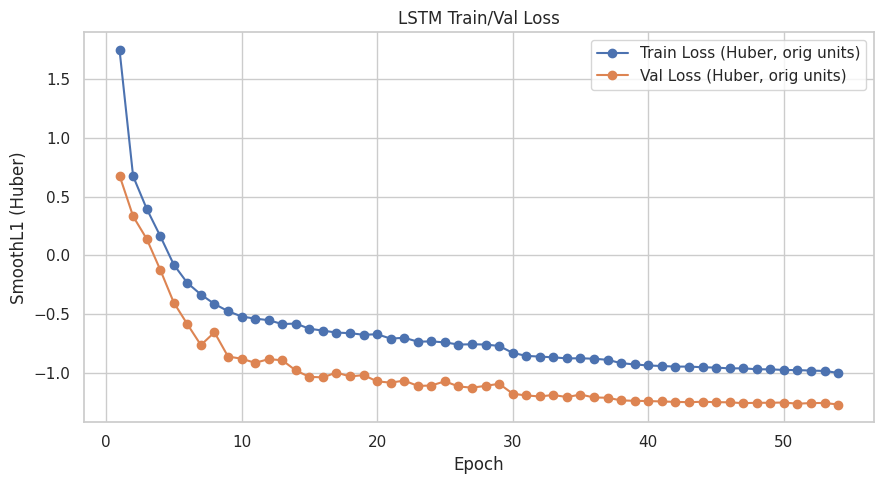

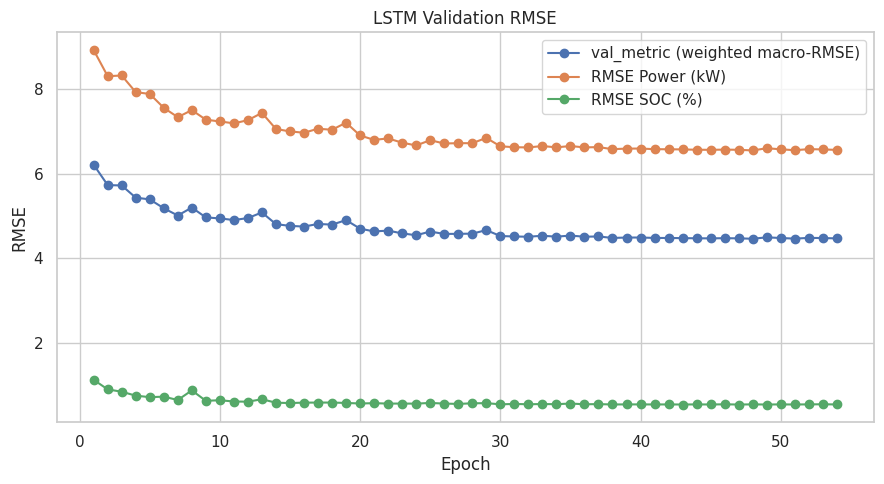

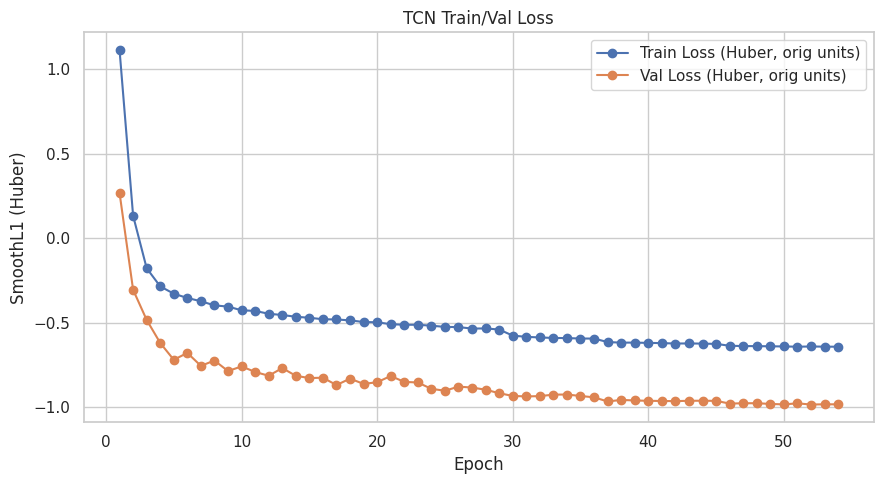

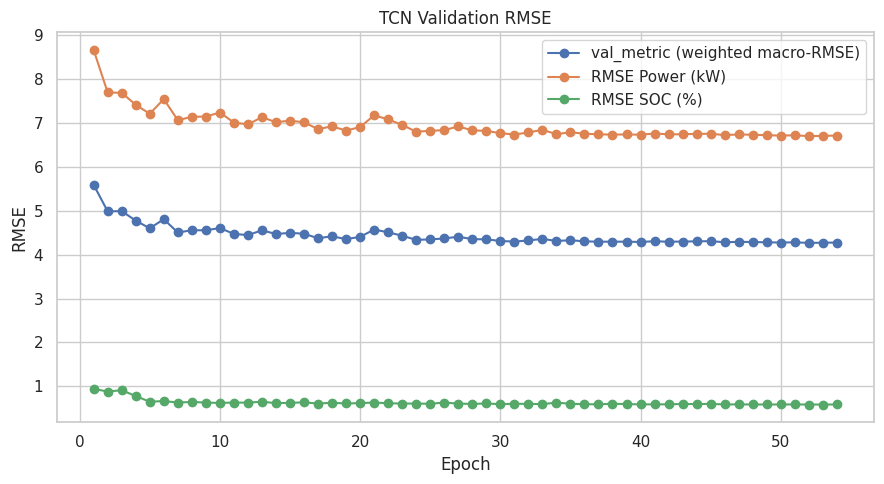

In [16]:
if best_lstm is not None: plot_best_curves(best_lstm, title_prefix="LSTM")
if best_tcn  is not None: plot_best_curves(best_tcn,  title_prefix="TCN")

The training curves show that both LSTM and TCN models converge steadily, with validation loss consistently below training loss. This happens because the use of dropout and gradient clipping during training injects noise that inflates the training loss, whereas validation is evaluated without these regularisers, leading to lower reported loss. Furthermore, the training loss is computed over longer and more diverse sequences, often including noisy or harder-to-predict segments, while the validation set may contain somewhat shorter or cleaner sequences. The use of the Huber loss also contributes: since it is more robust to outliers, validation loss is less penalised by extreme errors, while the training loss reflects the influence of a larger number of atypical or noisy samples. Across epochs, validation RMSE decreases and stabilises, with SOC predictions achieving the lowest error (≈0.5–0.6%) while power predictions remain more challenging (≈6–6.5 kW RMSE). 


 ## 5 - Model Evaluation and Selection
This section evaluates models across multiple metrics and selects the best performing architecture for further analysis.

### 5.1 Evaluating the models with macro averaging
To evaluate model performance across multiple horizons and target variables, we employ **Macro-Averaged Mean Squared Error (MSE)**.  




Given predictions $(\hat{y}_{t,h,c})$ and true values $(y_{t,h,c})$, where $(t)$ indexes time, $(h \in \{1,\dots,H\})$ denotes prediction horizon, and $(c \in \{1,\dots,C\})$ indexes target variables (e.g., power and SOC), the per-horizon-target MSE is defined as:

$$
\text{MSE}_{h,c} = \frac{1}{T_{h,c}} \sum_{t=1}^{T_{h,c}} \big( y_{t,h,c} - \hat{y}_{t,h,c} \big)^2
$$

where $(T_{h,c})$ is the number of valid predictions for horizon $(h)$ and target $(c)$.  
The **Macro-Averaged MSE** is then computed as:

$$
\text{MacroMSE} = \frac{1}{H \cdot C} \sum_{h=1}^{H} \sum_{c=1}^{C} \text{MSE}_{h,c}
$$

This metric gives equal weight to each horizon and each target variable, regardless of their scale or frequency.  

We use macro-averaging in this project because it prevents the evaluation from being dominated by a single variable (e.g., power, which has a larger numerical range than SOC) or by shorter horizons (which are typically easier to predict). By equally weighting horizons and targets, the Macro-Averaged MSE provides a balanced assessment of model performance across the entire forecasting problem.


In [17]:
def evaluate_model_macro_average(model: nn.Module,
                                 dataset: ChargingSessionDataset,
                                 batch_size: int,
                                 device: torch.device,
                                 power_scaler: MinMaxScaler,
                                 soc_scaler: MinMaxScaler):
    loader = DataLoader(dataset, batch_size=batch_size, collate_fn=session_collate_fn, shuffle=False)
    model.eval(); seq_mses = []
    with torch.no_grad():
        for X_batch, Y_batch, lengths in loader:
            X_batch = X_batch.to(device, non_blocking=True)
            Y_batch = Y_batch.to(device, non_blocking=True)
            pred_resid, _ = model(X_batch, lengths)
            pred = reconstruct_abs_from_residuals_batch(pred_resid, X_batch, IDX_POWER, IDX_SOC)

            B, Tm, H, C = pred.shape
            for i in range(B):
                L = lengths[i].item()
                if L <= H + 1: continue
                s, e = 1, L - H

                pred_scaled = pred[i, :L]
                true_resid  = Y_batch[i, :L]
                xi = X_batch[i, :L, [IDX_POWER, IDX_SOC]].unsqueeze(1).expand(-1, H, -1)
                true_abs_scaled = true_resid + xi

                pv = pred_scaled[s:e]; tv = true_abs_scaled[s:e]

                p_power = power_scaler.inverse_transform(pv[..., 0].contiguous().view(-1,1).cpu().numpy()).ravel()
                p_soc = soc_scaler.inverse_transform(pv[..., 1].contiguous().view(-1,1).cpu().numpy()).ravel()
                t_power = power_scaler.inverse_transform(tv[..., 0].contiguous().view(-1,1).cpu().numpy()).ravel()
                t_soc = soc_scaler.inverse_transform(tv[..., 1].contiguous().view(-1,1).cpu().numpy()).ravel()

                seq_mses.append(mean_squared_error(
                    np.concatenate([t_power, t_soc]), np.concatenate([p_power, p_soc])
                ))
    return {"MacroMSE": float(np.mean(seq_mses)) if seq_mses else float("nan"),
            "NumSequencesEvaluated": len(seq_mses)}


# -- Evaluate whichever models are available --
if model_lstm is not None:
    stats_lstm = evaluate_model_macro_average(model_lstm, test_dataset, BATCH_SIZE, DEVICE, power_scaler, soc_scaler)
    print(f"[LSTM] Test Macro-Averaged MSE: {stats_lstm['MacroMSE']:.4f} "
          f"(across {stats_lstm['NumSequencesEvaluated']} sequences)")

if model_tcn is not None:
    stats_tcn = evaluate_model_macro_average(model_tcn, test_dataset, BATCH_SIZE, DEVICE, power_scaler, soc_scaler)
    print(f"[TCN]  Test Macro-Averaged MSE: {stats_tcn['MacroMSE']:.4f} "
          f"(across {stats_tcn['NumSequencesEvaluated']} sequences)")

[LSTM] Test Macro-Averaged MSE: 21.6752 (across 12183 sequences)
[TCN]  Test Macro-Averaged MSE: 22.4614 (across 12183 sequences)


 ### 5.2 Plotting Predictions
In this section, we will inspect the models' predictions on individual charging sessions in order to better understand the models' behaviour. 

#### 5.2.1 Plotting Setup and Utility Functions
The utility functions below help prepare and align predictions with ground truth for visualisation.

In [18]:
def _valid_time_bounds(T: int, H: int):
    return 1, max(1, T - H)  # [start, end_exclusive]


# -- Reconstruct absolute predictions from a bundle (scaled space) --
def reconstruct_abs_from_bundle(bundle: SessionPredsBundle, idx_power: int, idx_soc: int):
    base = bundle.X_sample[:, [idx_power, idx_soc]].unsqueeze(1)
    return bundle.P_sample + base

# -- Plot inputs (orig units) vs single future point (pred/true) --
def plot_inputs_to_single_output_grid(bundle: SessionPredsBundle, i_list: List[int], horizon: int=1,
                                      target: str="power", features_to_show: Optional[List[str]]=None,
                                      power_scaler=None, soc_scaler=None, window_len: Optional[int]=30,
                                      ncols: int=3, right_pad_steps: float=1.8, annotate: bool=True,
                                      enforce_same_units: bool=True):
    assert target in {"power","soc"}
    H, T = bundle.horizon, bundle.length
    h = max(1, min(horizon, H))
    start_valid, end_valid_excl = _valid_time_bounds(T, H)

    clamped = []
    for i0 in i_list:
        j = min(max(i0, start_valid), end_valid_excl - 1)
        if start_valid <= j < end_valid_excl: clamped.append(j)
    if not clamped: raise ValueError(f"No valid i0; valid range is 1..{T-H-1}.")

    power_unscaled = bundle.true_power_unscaled
    soc_unscaled   = bundle.true_soc_unscaled

    feats_map = {"power": power_unscaled, "soc": soc_unscaled}
    if features_to_show is None:
        features_to_show = ["power"] if target == "power" else ["soc"]
    if enforce_same_units:
        allowed = {"power"} if target == "power" else {"soc"}
        features_to_show = [f for f in features_to_show if f in allowed]
        if not features_to_show: features_to_show = list(allowed)
    else:
        features_to_show = [f for f in features_to_show if f in feats_map]

    t_scaler = power_scaler if target == "power" else soc_scaler
    target_idx = 0 if target == "power" else 1
    y_label = "Power (kW)" if target == "power" else "SOC (%)"

    n = len(clamped); ncols = max(1, ncols); nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(6.2*ncols, 4.2*nrows), squeeze=False)
    palette = sns.color_palette("deep", n_colors=len(features_to_show))

    P_abs = reconstruct_abs_from_bundle(bundle, IDX_POWER, IDX_SOC)

    for ax, i0 in zip(axes.ravel(), clamped):
        if window_len is None: w0, w1 = 0, i0 + 1
        else: w0, w1 = max(0, i0 - window_len + 1), i0 + 1
        tt = np.arange(w0, w1)

        ymins, ymaxs = [], []
        for ci, f in enumerate(features_to_show):
            series = feats_map[f][w0:w1]
            ax.plot(tt, series, label=f, linewidth=2, color=palette[ci])
            ymins.append(series.min()); ymaxs.append(series.max())

        t_pred = i0 + h
        y_pred = P_abs[i0, h-1, target_idx].numpy().reshape(1,1)
        base_i = bundle.X_sample[i0, [IDX_POWER, IDX_SOC]][target_idx].item()
        y_true = np.array([[bundle.Y_sample[i0, h-1, target_idx].item() + base_i]], dtype=np.float32)

        y_pred = t_scaler.inverse_transform(y_pred).ravel()[0]
        y_true = t_scaler.inverse_transform(y_true).ravel()[0]

        ax.scatter([t_pred], [y_pred], s=120, marker="x", linewidths=2.5, color="tab:red",  zorder=5, label="Pred")
        ax.scatter([t_pred], [y_true], s=120, marker="x", linewidths=2.5, color="tab:blue", zorder=5, label="True")

        if annotate:
            ax.annotate(f"{y_pred:.2f}", (t_pred, y_pred), textcoords="offset points", xytext=(6, 8),  fontsize=8, color="tab:red")
            ax.annotate(f"{y_true:.2f}", (t_pred, y_true), textcoords="offset points", xytext=(6,-14), fontsize=8, color="tab:blue")

        ymins.append(min(y_pred, y_true)); ymaxs.append(max(y_pred, y_true))
        y_lo, y_hi = min(ymins), max(ymaxs); span = max(1e-9, y_hi - y_lo); pad = 0.08 * span if span > 0 else 0.5
        ax.set_ylim(y_lo - pad, y_hi + pad)

        ax.axvline(i0, color="black", linestyle=":", linewidth=1.8)
        ax.set_xlim(min(w0, t_pred), max(w1 - 1, t_pred) + right_pad_steps)

        ax.set_title(f"i0={i0}, H={h} → t={t_pred} | batch {bundle.batch_index}, sample {bundle.sample_index}")
        ax.set_xlabel("Time index"); ax.set_ylabel(y_label)
        ax.grid(True); ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True)); ax.legend(fontsize=8, loc="upper left")

    for k in range(len(clamped), nrows*ncols):
        axes.ravel()[k].set_axis_off()
    fig.suptitle(f"Inputs → Single {target.upper()} output @ H={h}", y=1.02, fontsize=12)
    plt.tight_layout(); plt.show()


# -- Test loader for plotting (fixed order; no shuffle) --
test_sampler  = BucketBatchSampler(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader   = DataLoader(test_dataset, batch_sampler=test_sampler, collate_fn=session_collate_fn,
                           num_workers=NUM_WORKERS, pin_memory=True, prefetch_factor=2)

#### 5.2.2 Plotting input-output pairs at time $t$ for a single session
Grid plots display how well the model predicts specific outputs at different horizons, allowing horizon-wise error inspection.


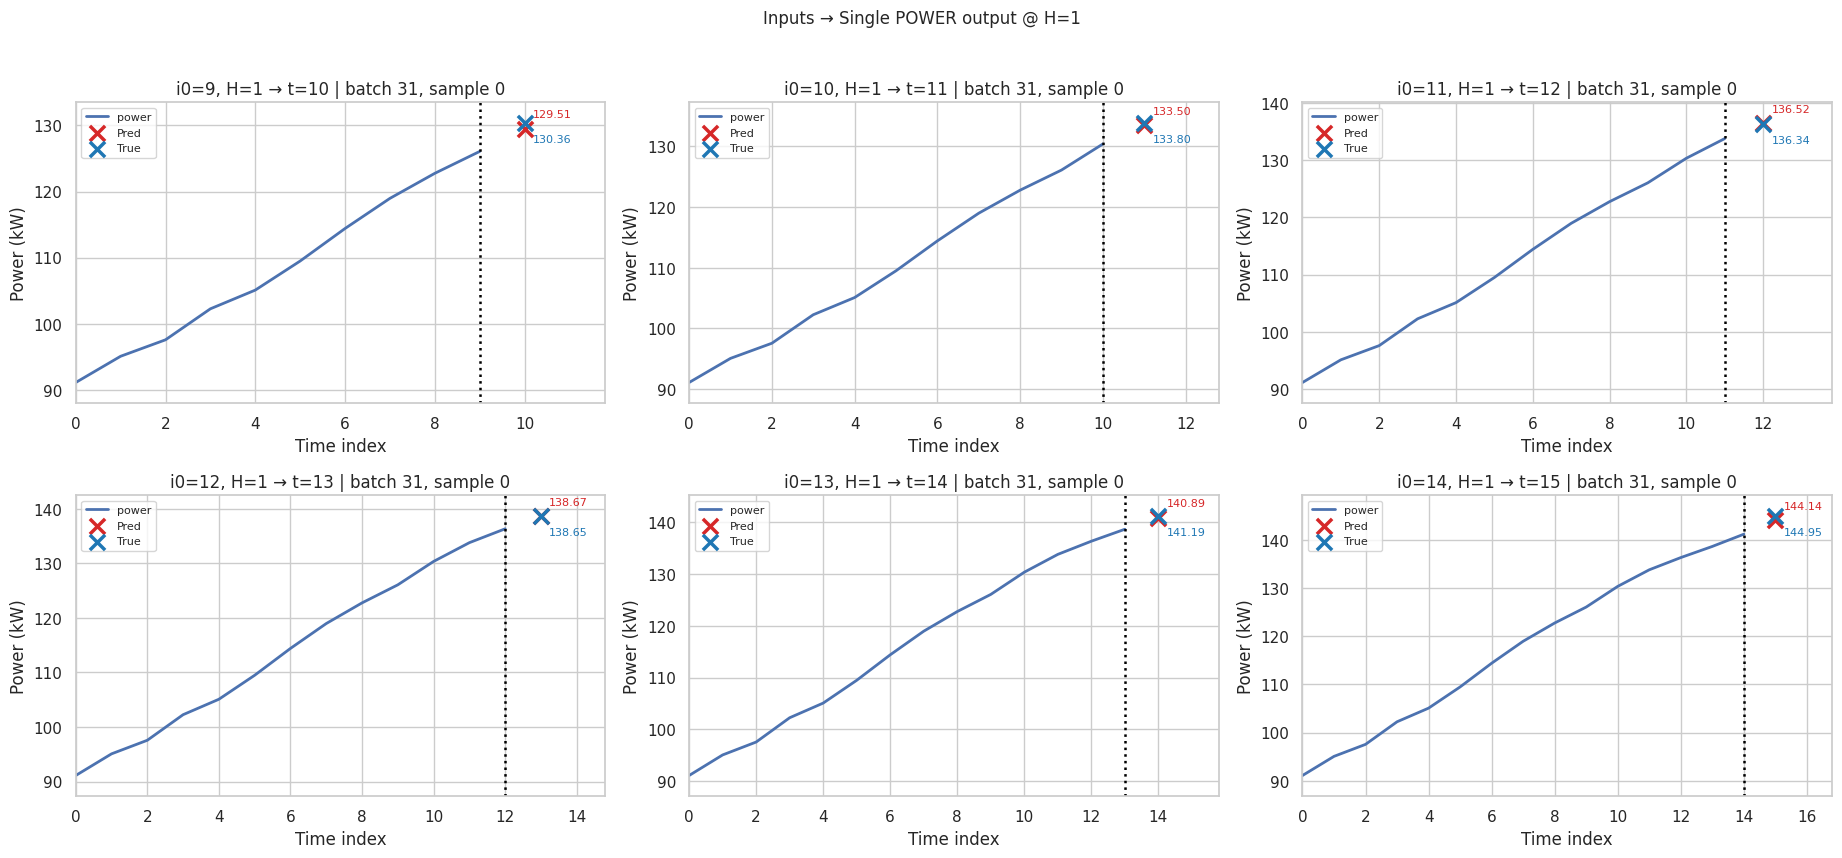

In [19]:
# Create sample bundles 
BATCH_INDEX, SAMPLE_INDEX = 31, 0   # For selecting the session (from batch) we want to plot predictions for
bundle_lstm = (fetch_session_preds_bundle(model_lstm, test_loader, BATCH_INDEX, SAMPLE_INDEX, DEVICE, power_scaler, soc_scaler, IDX_POWER, IDX_SOC)
               if model_lstm is not None else None)
bundle_tcn  = (fetch_session_preds_bundle(model_tcn,  test_loader, BATCH_INDEX, SAMPLE_INDEX, DEVICE, power_scaler, soc_scaler, IDX_POWER, IDX_SOC)
               if model_tcn  is not None else None)

if bundle_lstm is not None:
    plot_inputs_to_single_output_grid(bundle_lstm, i_list=[9,10,11,12,13,14], horizon=1, target="power",
                                      features_to_show=["power"], power_scaler=power_scaler, soc_scaler=soc_scaler,
                                      window_len=30, ncols=3, enforce_same_units=True)

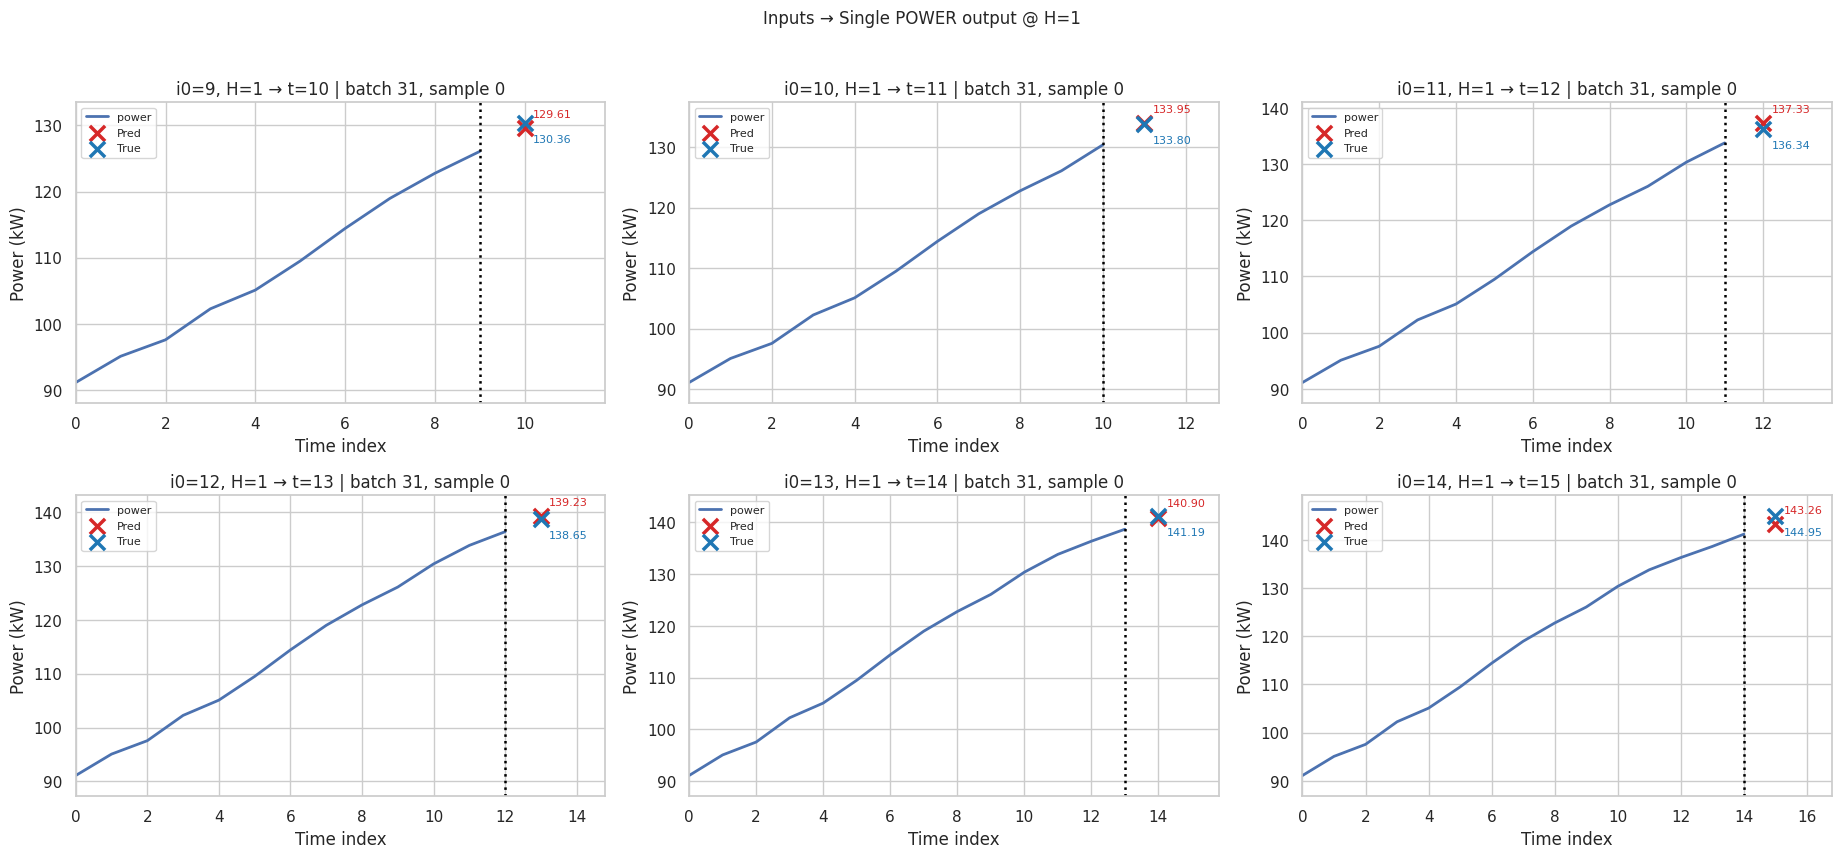

In [20]:
if bundle_tcn is not None:
    plot_inputs_to_single_output_grid(bundle_tcn, i_list=[9,10,11,12,13,14], horizon=1, target="power",
                                      features_to_show=["power"], power_scaler=power_scaler, soc_scaler=soc_scaler,
                                      window_len=30, ncols=3, enforce_same_units=True)

#### 5.2.3 Plotting Multi-Horizon Predictions for a Full Session
Plots of entire sessions show model predictions across horizons, illustrating temporal coherence of forecasts.

In [21]:
def plot_full_session(bundle: SessionPredsBundle, power_scaler, soc_scaler, target="power", title_suffix=""):
    assert target in {"power","soc"}
    T, H = bundle.length, bundle.horizon
    t = np.arange(T); idx = 0 if target=="power" else 1
    scaler = power_scaler if target=="power" else soc_scaler
    true = bundle.true_power_unscaled if idx==0 else bundle.true_soc_unscaled

    plt.figure(figsize=(10,5))
    sns.lineplot(x=t, y=true, color="black", linewidth=2.5, label=f"True {target.title()}")

    palette = sns.color_palette("deep", n_colors=H)
    P_abs = reconstruct_abs_from_bundle(bundle, IDX_POWER, IDX_SOC)
    for h0 in range(H):
        i_valid = np.arange(1, T - (h0+1))
        t_abs = i_valid + (h0+1)
        preds = scaler.inverse_transform(P_abs[i_valid, h0, idx].numpy().reshape(-1,1)).ravel()
        sns.lineplot(x=t_abs, y=preds, linestyle="--", linewidth=1.8, color=palette[h0],
                     label=f"Horizon={h0+1}", marker="o", markersize=3)
        plt.scatter(t_abs, preds, s=10, color=palette[h0], alpha=0.5)

    plt.title(f"{target.upper()} predictions — batch {bundle.batch_index}, sample {bundle.sample_index}{title_suffix}")
    plt.xlabel("Time index"); plt.ylabel("Power (kW)" if idx==0 else "SOC (%)")
    plt.grid(True); plt.gca().xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
    plt.legend(); plt.tight_layout(); plt.show()
    plt.tight_layout(); plt.show()

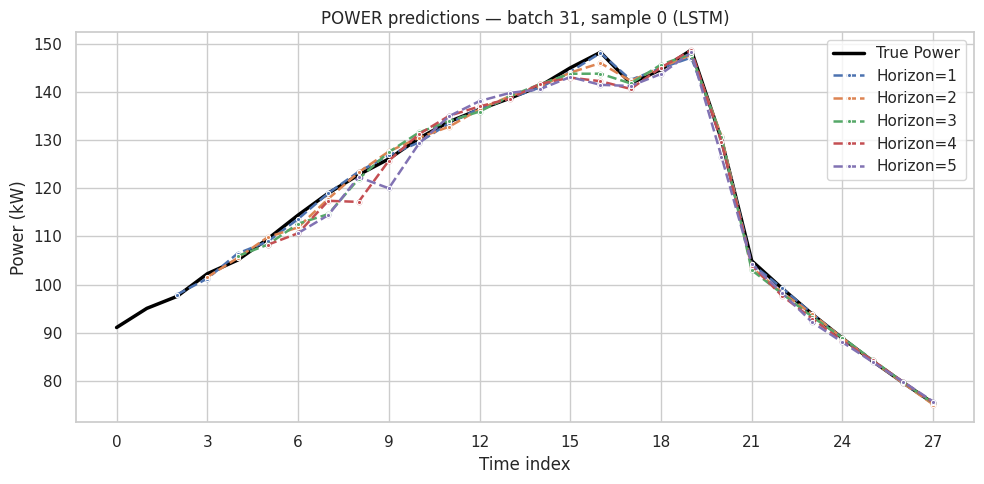

<Figure size 640x480 with 0 Axes>

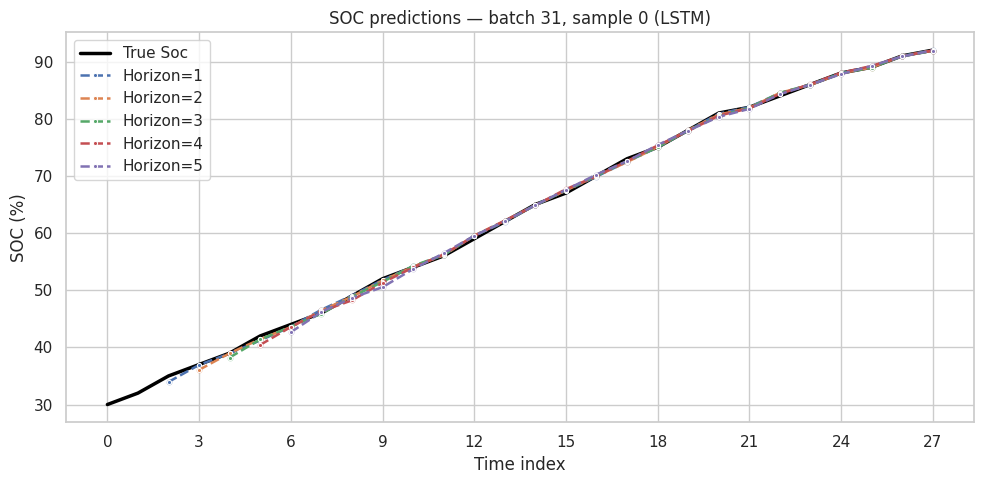

<Figure size 640x480 with 0 Axes>

In [22]:
if bundle_lstm is not None:
    plot_full_session(bundle_lstm, power_scaler, soc_scaler, target="power", title_suffix=" (LSTM)")
    plot_full_session(bundle_lstm, power_scaler, soc_scaler, target="soc",   title_suffix=" (LSTM)")

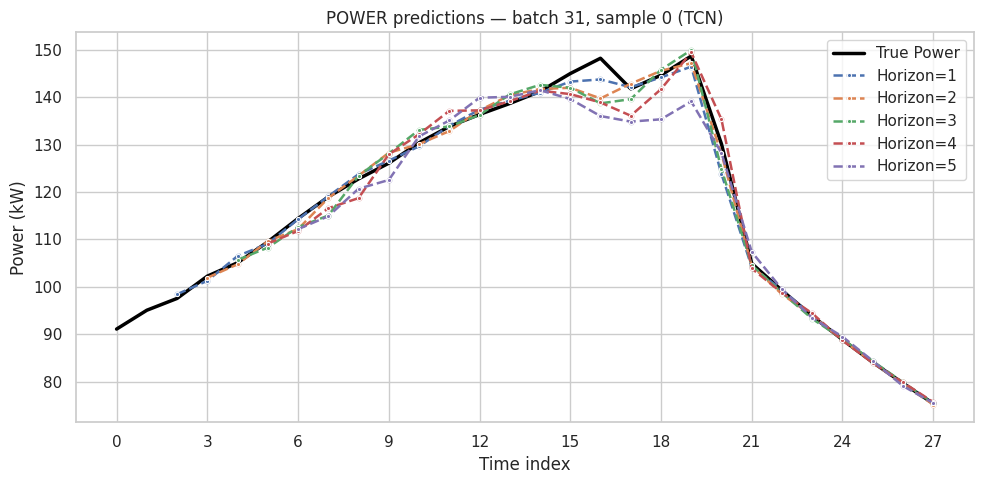

<Figure size 640x480 with 0 Axes>

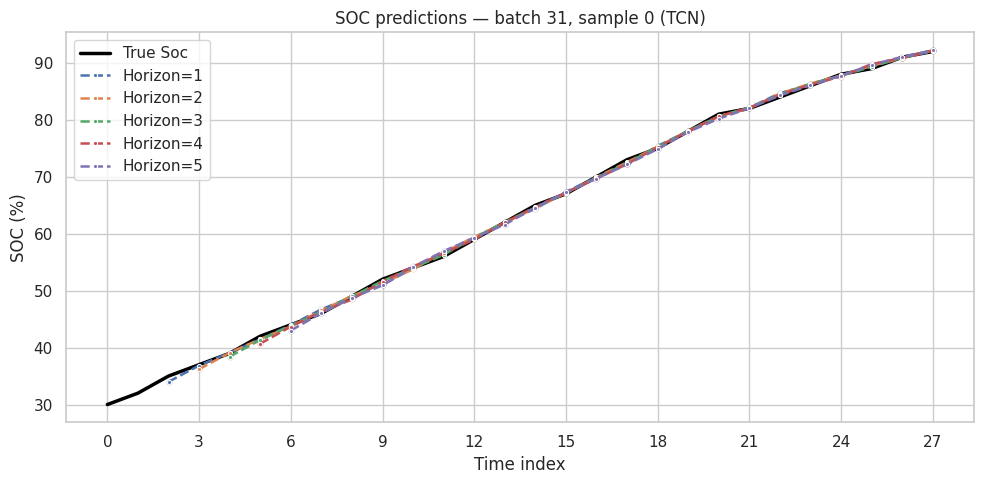

<Figure size 640x480 with 0 Axes>

In [23]:
if bundle_tcn is not None:
    plot_full_session(bundle_tcn, power_scaler, soc_scaler, target="power", title_suffix=" (TCN)")
    plot_full_session(bundle_tcn, power_scaler, soc_scaler, target="soc",   title_suffix=" (TCN)")

#### 5.2.4 Plotting Complete Power Predictions for Multiple Sample Sessions
Predicted and true power curves are compared across multiple sessions to evaluate generalisation.

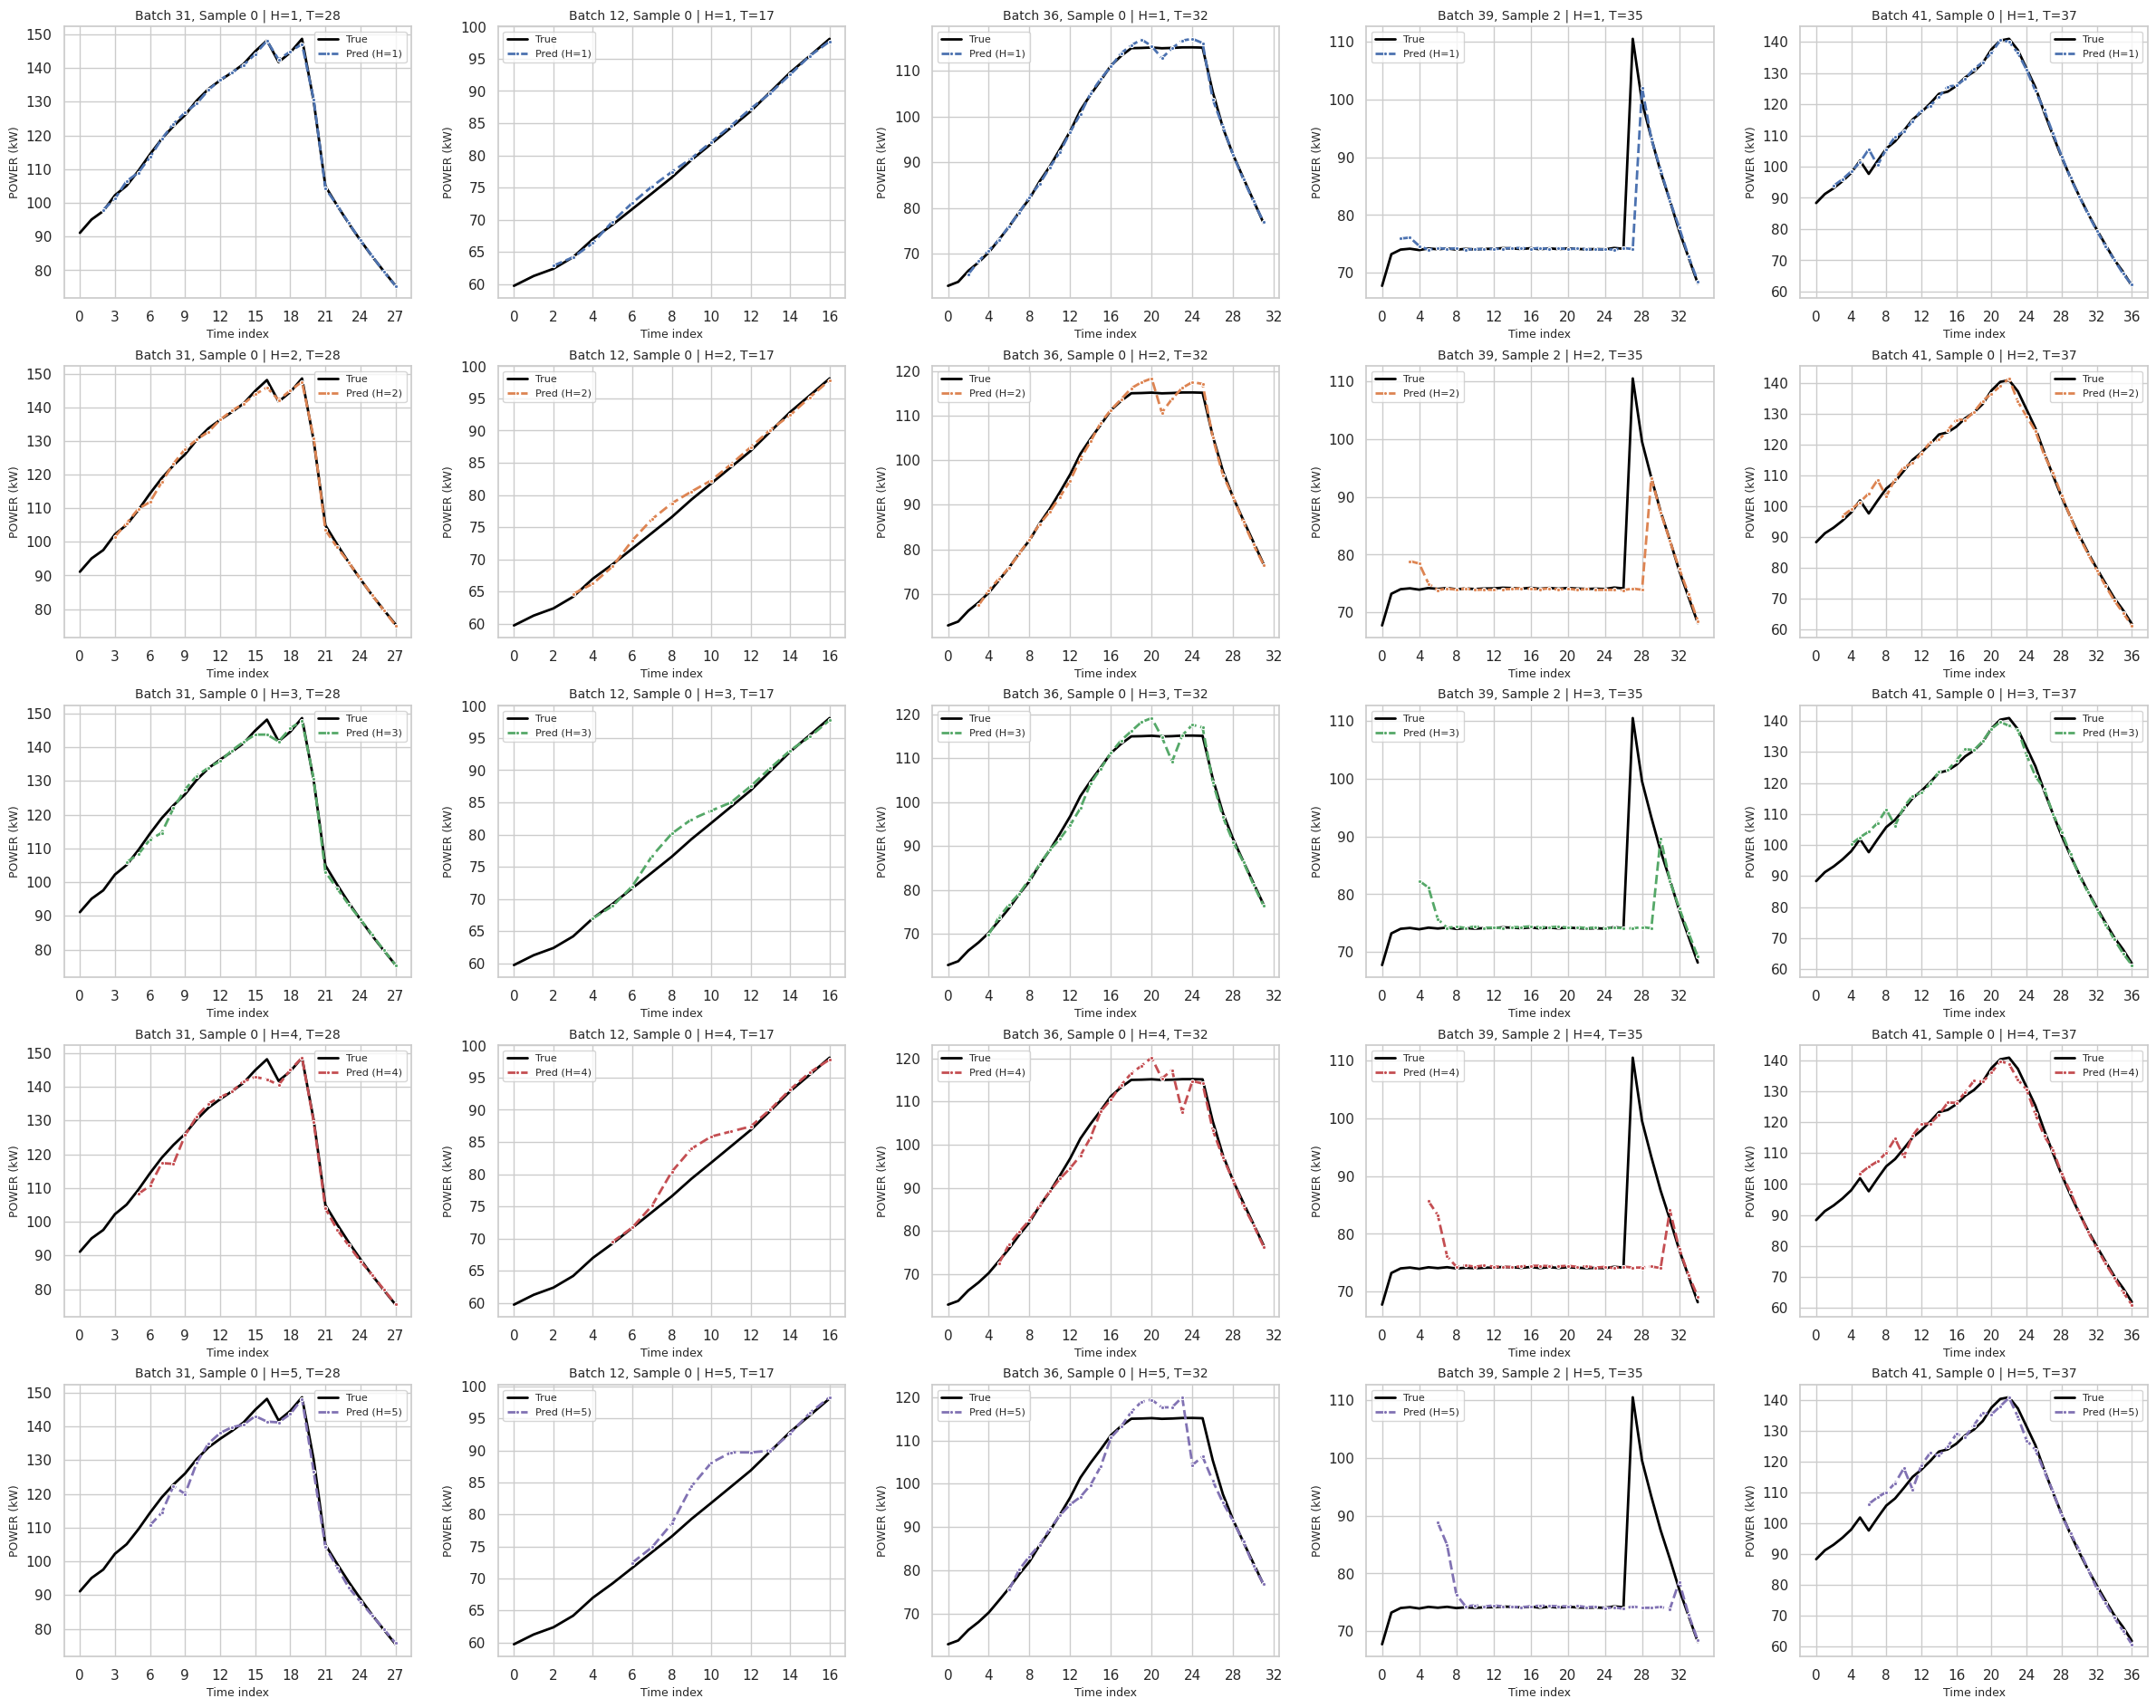

In [24]:
def plot_grid_by_horizon(bundles: List[SessionPredsBundle], power_scaler, soc_scaler, target: str="power"):
    assert target in {"power","soc"}
    H = bundles[0].horizon; target_idx = 0 if target=="power" else 1
    scaler = power_scaler if target=="power" else soc_scaler
    ncols = len(bundles)

    fig, axes = plt.subplots(
        nrows=H, ncols=ncols,
        figsize=(5*ncols, 4*H),
        squeeze=False, sharex=False, sharey=False
    )
    fig.subplots_adjust(hspace=0.25, wspace=0.25, left=0.06, right=0.98, top=0.96, bottom=0.06)

    label_fs = 9
    title_fs = 10 
    palette = sns.color_palette("deep", n_colors=H)

    for col, b in enumerate(bundles):
        T = b.length; t_true = np.arange(T)
        true_unscaled = b.true_power_unscaled if target_idx==0 else b.true_soc_unscaled
        for h0 in range(H):
            ax = axes[h0, col]; h1 = h0 + 1
            i_valid = np.arange(1, T - h1)
            if i_valid.size == 0:
                ax.text(0.5, 0.5, "No valid preds", ha="center", va="center"); ax.set_axis_off(); continue
            t_pred = i_valid + h1
            P_abs = reconstruct_abs_from_bundle(b, IDX_POWER, IDX_SOC)
            preds = scaler.inverse_transform(P_abs[i_valid, h0, target_idx].numpy().reshape(-1,1)).ravel()

            sns.lineplot(x=t_true, y=true_unscaled, color="black", linewidth=2, label="True", ax=ax)
            sns.lineplot(x=t_pred, y=preds, linestyle="--", linewidth=2, color=palette[h0],
                         label=f"Pred (H={h1})", marker="o", markersize=3, ax=ax)

            ax.set_title(f"Batch {b.batch_index}, Sample {b.sample_index} | H={h1}, T={T}", fontsize=title_fs)
            ax.set_xlabel("Time index", fontsize=label_fs)
            ax.set_ylabel("POWER (kW)" if target_idx==0 else "SOC (%)", fontsize=label_fs)
            ax.grid(True)
            ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
            ax.legend(fontsize=8)


if model_lstm is not None:
    bundles_l = [
        fetch_session_preds_bundle(model_lstm, test_loader, BATCH_INDEX, SAMPLE_INDEX, DEVICE, power_scaler, soc_scaler, IDX_POWER, IDX_SOC),
        fetch_session_preds_bundle(model_lstm, test_loader, 12, 0, DEVICE, power_scaler, soc_scaler, IDX_POWER, IDX_SOC),
        fetch_session_preds_bundle(model_lstm, test_loader, 36, 0, DEVICE, power_scaler, soc_scaler, IDX_POWER, IDX_SOC),
        fetch_session_preds_bundle(model_tcn, test_loader, 39, 2, DEVICE, power_scaler, soc_scaler, IDX_POWER, IDX_SOC),
        fetch_session_preds_bundle(model_tcn, test_loader, 41, 0, DEVICE, power_scaler, soc_scaler, IDX_POWER, IDX_SOC),
    ]
    plot_grid_by_horizon(bundles_l, power_scaler, soc_scaler, target="power")

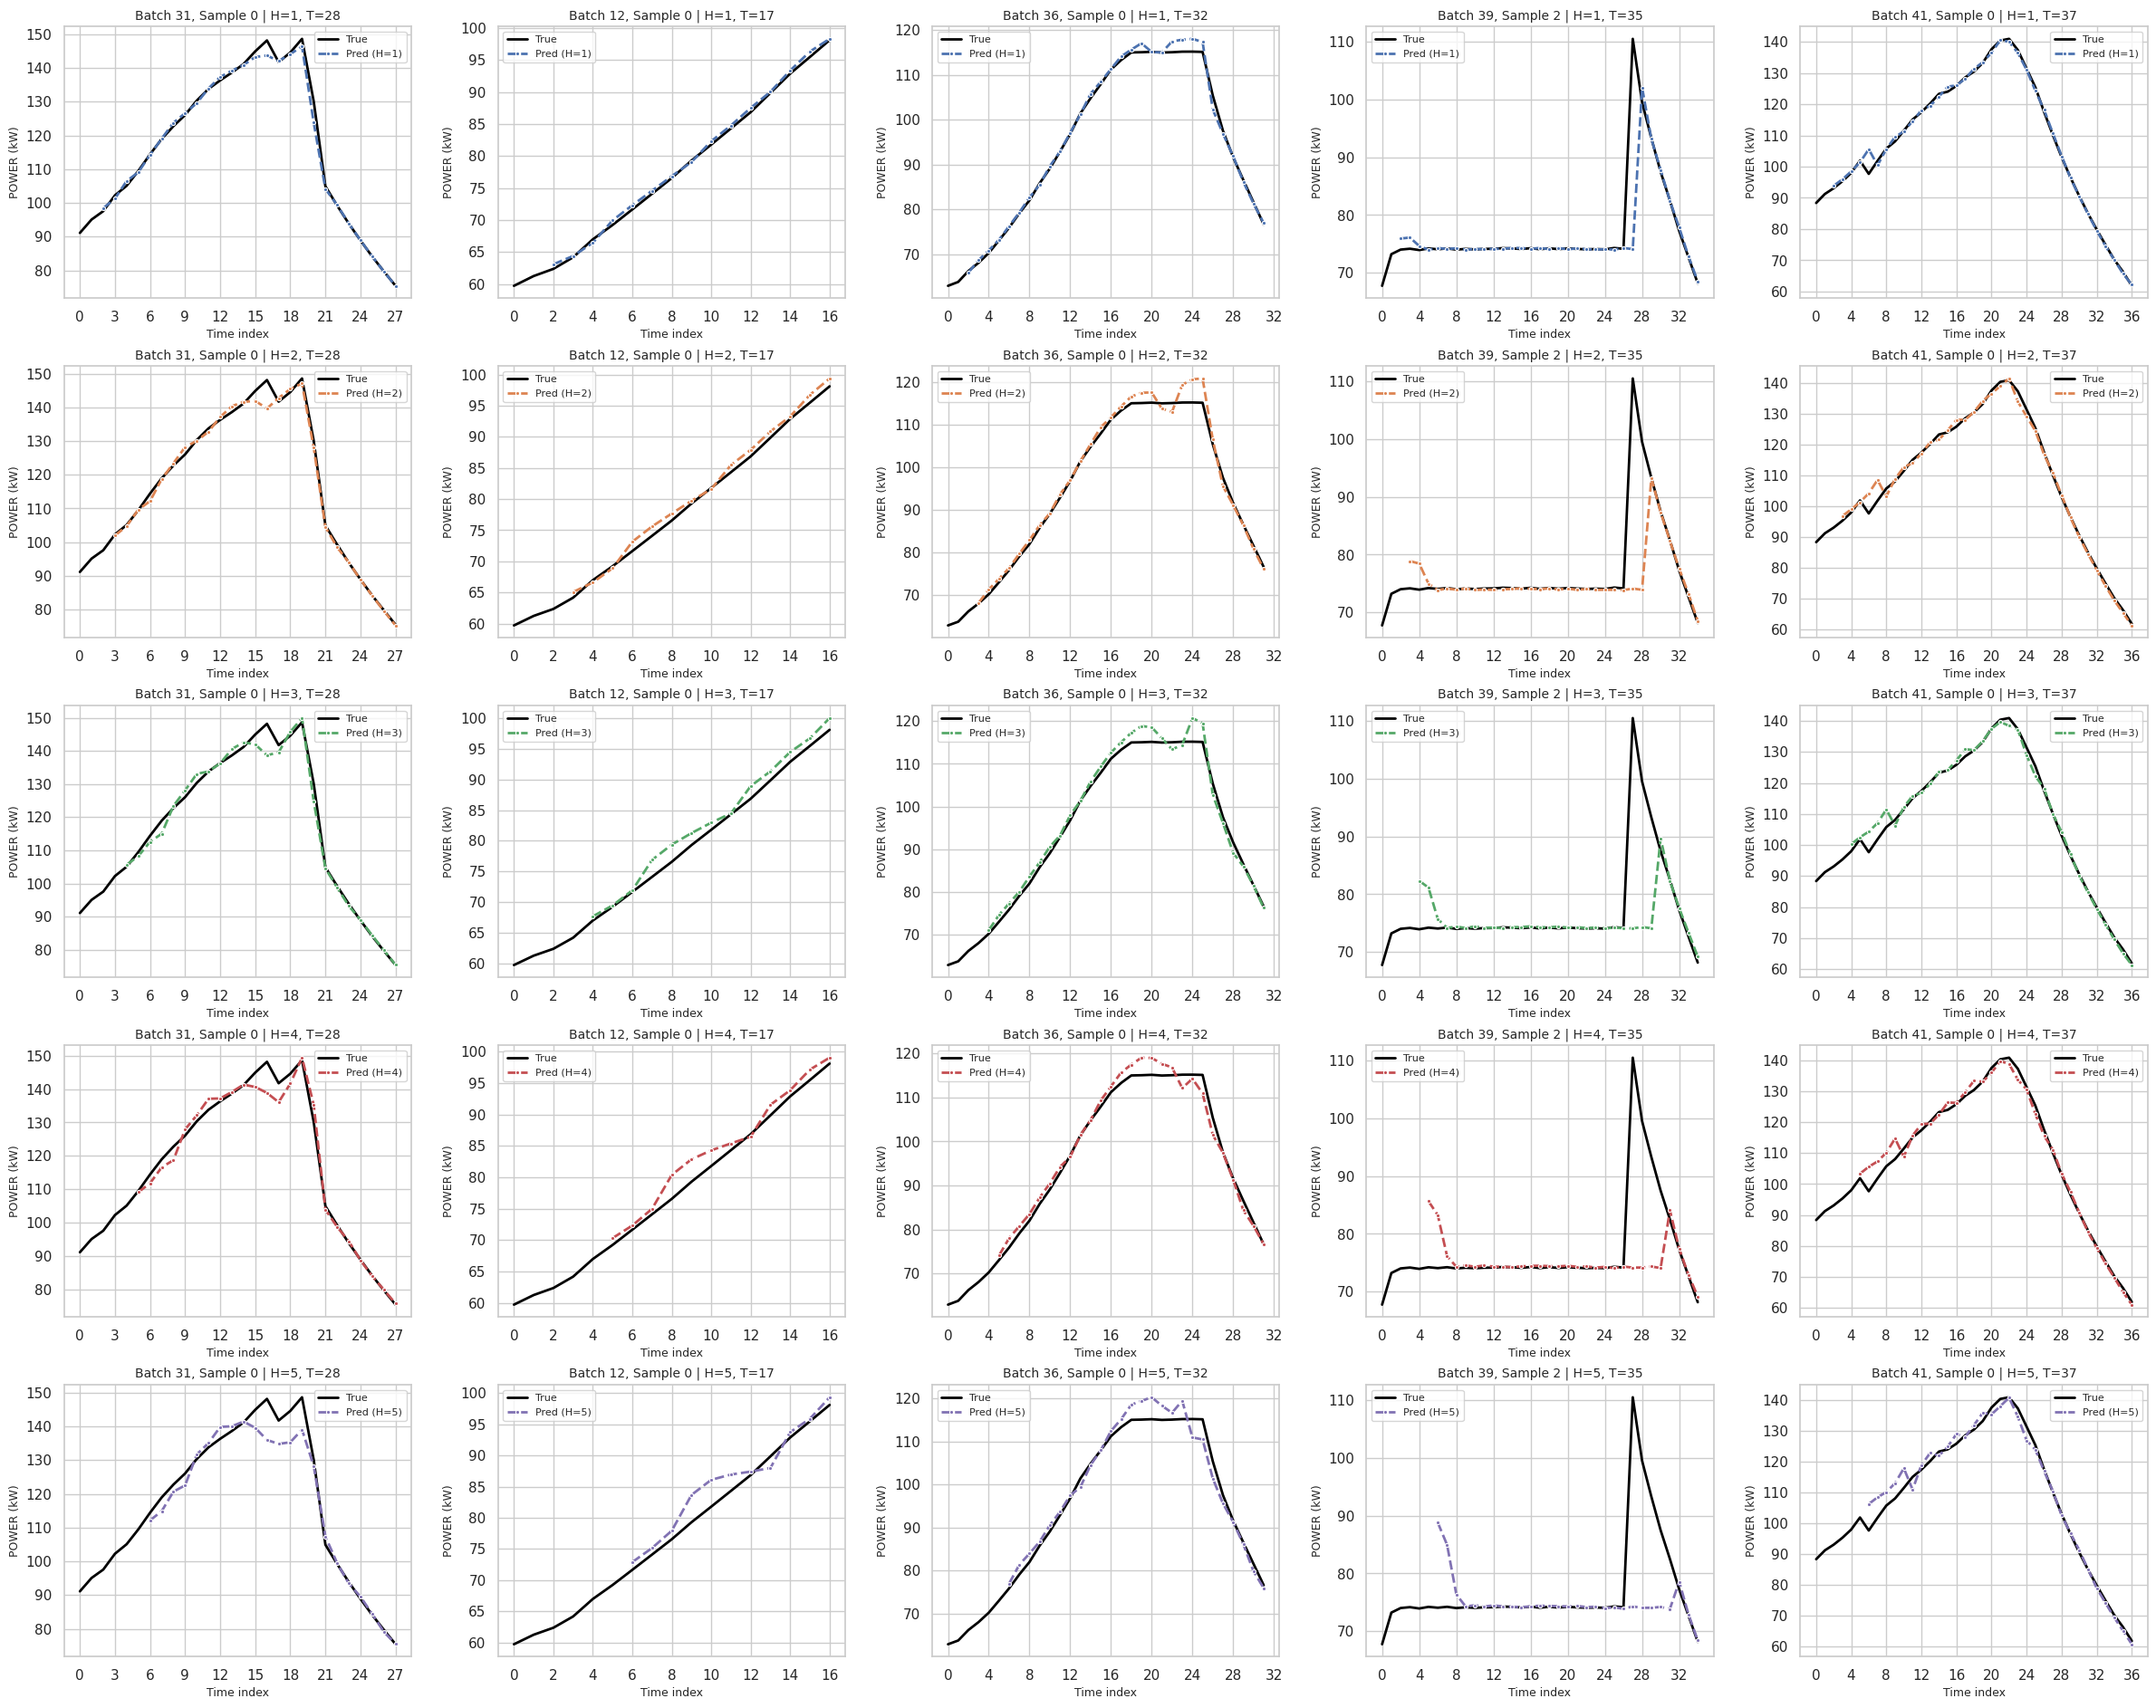

In [25]:
if model_tcn is not None:
    bundles_c = [
        fetch_session_preds_bundle(model_tcn, test_loader, BATCH_INDEX, SAMPLE_INDEX, DEVICE, power_scaler, soc_scaler, IDX_POWER, IDX_SOC),
        fetch_session_preds_bundle(model_tcn, test_loader, 12, 0, DEVICE, power_scaler, soc_scaler, IDX_POWER, IDX_SOC),
        fetch_session_preds_bundle(model_tcn, test_loader, 36, 0, DEVICE, power_scaler, soc_scaler, IDX_POWER, IDX_SOC),
        fetch_session_preds_bundle(model_tcn, test_loader, 39, 2, DEVICE, power_scaler, soc_scaler, IDX_POWER, IDX_SOC),
        fetch_session_preds_bundle(model_tcn, test_loader, 41, 0, DEVICE, power_scaler, soc_scaler, IDX_POWER, IDX_SOC),
    ]
    plot_grid_by_horizon(bundles_c, power_scaler, soc_scaler, target="power")

### 5.3 Model Selection
We have conducted a quantitative (MacroMSE) and qualitative (prediction plots) evaluation of the models. The best LSTM model `LSTM_multihorizon_raytuned_model_7.pth` performed slightly better than the best TCN model when tested on the MacroMSE benchmark, so we will continue with the LSTM for the task of anomaly detection. 

In [26]:
# Save the selected model with its state dict and Ray Tune config 
cfg_lstm["horizon"] = HORIZON
torch.save({
    "model_state_dict": model_lstm.state_dict(),
    "config": cfg_lstm,  # Ray Tune best config
    "input_features": input_features,  # to reconstruct input size
    "target_features": target_features
}, os.path.join(MODEL_FOLDER_PATH, "final/final_model.pth"))


### 5.4 Summary and Next Steps

We compared two sequence models—an LSTM and a TCN—trained to predict multi-horizon trajectories for power and SOC. Evaluation used **MacroMSE** to weight horizons and targets equally. The **LSTM** outperformed the **TCN** on the test set (21.3 vs 22.3) and is adopted as the final forecaster for the anomaly-detection stage. Tuned checkpoints were restored and saved to versioned `.pth` files to ensure reproducibility. 


**Next steps:**
1. Notebook 4: [Anomaly Detection](04__Anomaly_Detection_v1.ipynb)
2. Notebook 5: [Curve Simplification](05__Curve_Simplification_v1.ipynb)
3. Notebook 6: [MT4XAI Test](06__MT4XAI_test_v1.ipynb)
4. ...